In [2]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# --- Configuration ---
BASE_PATH = "train_data"
SENSORS = ['Accelerometer', 'Gyroscope', 'Linear Acceleration']
print(f"Looking for data in: '{BASE_PATH}/'")
print(f"Processing sensors: {SENSORS}")
print("-" * 50)

def discover_data_structure(base_path):
    """Scans the directory to find all exercise recordings."""
    data_paths = []
    p = Path(base_path)
    if not p.exists():
        print(f"❌ Error: Base directory not found at '{base_path}'")
        return data_paths
        
    for exercise_p in p.iterdir():
        if exercise_p.is_dir():
            for participant_p in exercise_p.iterdir():
                if participant_p.is_dir():
                    for dataset_p in participant_p.iterdir():
                        if dataset_p.is_dir():
                            sensor_files = {}
                            for sensor in SENSORS:
                                sensor_file = dataset_p / f"{sensor}.csv"
                                if sensor_file.exists():
                                    sensor_files[sensor] = sensor_file
                            
                            if sensor_files: # Only add if there's at least one sensor file
                                data_paths.append({
                                    'exercise': exercise_p.name,
                                    'participant': participant_p.name,
                                    'dataset': dataset_p.name,
                                    'sensor_files': sensor_files
                                })
    return data_paths

def load_and_merge_sensors(recording_info):
    """Loads, standardizes, and merges all sensors for a single recording."""
    merged_data = None
    
    # Standardize column names for merging
    column_mappings = {
        'Accelerometer': {'X (m/s^2)': 'acc_x', 'Y (m/s^2)': 'acc_y', 'Z (m/s^2)': 'acc_z'},
        'Gyroscope': {'X (rad/s)': 'gyro_x', 'Y (rad/s)': 'gyro_y', 'Z (rad/s)': 'gyro_z'},
        'Linear Acceleration': {'X (m/s^2)': 'lin_acc_x', 'Y (m/s^2)': 'lin_acc_y', 'Z (m/s^2)': 'lin_acc_z'}
    }

    for sensor, file_path in recording_info['sensor_files'].items():
        try:
            sensor_df = pd.read_csv(file_path)
            # Rename columns to be standardized
            sensor_df = sensor_df.rename(columns=column_mappings.get(sensor, {}))
            
            if merged_data is None:
                merged_data = sensor_df
            else:
                # Merge on time, using an outer join to keep all data points
                merged_data = pd.merge(merged_data, sensor_df, on='Time (s)', how='outer')
        except Exception as e:
            print(f"  ⚠️ Could not load {file_path}: {e}")
            return None

    if merged_data is None:
        return None

    # Sort by time and handle missing values
    merged_data = merged_data.sort_values('Time (s)').reset_index(drop=True)
    
    # Interpolate missing values
    sensor_cols = [col for col in merged_data.columns if col != 'Time (s)']
    merged_data[sensor_cols] = merged_data[sensor_cols].interpolate(method='linear').ffill().bfill()
    
    # Add metadata
    merged_data['exercise'] = recording_info['exercise']
    merged_data['participant'] = recording_info['participant']
    merged_data['dataset'] = recording_info['dataset']
    
    return merged_data

# --- Main Execution ---
print("🚀 Discovering and loading all datasets...")
all_recordings = discover_data_structure(BASE_PATH)
all_timeseries = []

if not all_recordings:
    print("No recordings found. Please check the BASE_PATH.")
else:
    print(f"Found {len(all_recordings)} recordings.")
    for i, rec_info in enumerate(all_recordings):
        print(f"  Processing {i+1}/{len(all_recordings)}: {rec_info['exercise']}/{rec_info['participant']}/{rec_info['dataset']}...")
        df = load_and_merge_sensors(rec_info)
        if df is not None:
            all_timeseries.append(df)
    
    print("-" * 50)
    print(f"✅ Successfully loaded {len(all_timeseries)} timeseries datasets.")


Looking for data in: 'train_data/'
Processing sensors: ['Accelerometer', 'Gyroscope', 'Linear Acceleration']
--------------------------------------------------
🚀 Discovering and loading all datasets...
Found 24 recordings.
  Processing 1/24: squats/akshaye/squats1...
  Processing 2/24: squats/akshaye/squats2...
  Processing 3/24: squats/akshaye/squats3...
  Processing 4/24: squats/swasti/squats1...
  Processing 5/24: squats/swasti/squats2...
  Processing 6/24: squats/swasti/squats3...
  Processing 7/24: crunches/akshaye/crunches1...
  Processing 8/24: crunches/swasti/crunches1...
  Processing 9/24: crunches/swasti/crunches2...
  Processing 10/24: crunches/swasti/crunches3...
  Processing 11/24: jumping_jacks/akshaye/jumping_jacks3...
  Processing 12/24: jumping_jacks/akshaye/jumping_jacks2...
  Processing 13/24: jumping_jacks/akshaye/jumping_jacks_set1...
  Processing 14/24: jumping_jacks/swasti/jumping_jacks3...
  Processing 15/24: jumping_jacks/swasti/jumping_jacks2...
  Processing 1

In [3]:
# def plot_raw_signal(df, title="Raw Sensor Data"):
#     """
#     Plots key sensor features over time and annotates example regions.
#     """
#     if df is None or df.empty:
#         print("DataFrame is empty. Cannot plot.")
#         return

#     # Define which columns to plot
#     accel_cols = ['acc_x', 'acc_y', 'acc_z']
#     gyro_cols = ['gyro_x', 'gyro_y', 'gyro_z']
    
#     # Check which columns are actually in the dataframe
#     plot_accel = [c for c in accel_cols if c in df.columns]
#     plot_gyro = [c for c in gyro_cols if c in df.columns]

#     fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True)
#     fig.suptitle(title, fontsize=16)

#     # Plot Accelerometer
#     if plot_accel:
#         axes[0].plot(df['Time (s)'], df[plot_accel])
#         axes[0].set_ylabel('Acceleration (m/s^2)')
#         axes[0].legend(plot_accel)
#         axes[0].set_title('Accelerometer')
#         axes[0].grid(True, alpha=0.4)

#     # Plot Gyroscope
#     if plot_gyro:
#         axes[1].plot(df['Time (s)'], df[plot_gyro])
#         axes[1].set_ylabel('Rotation (rad/s)')
#         axes[1].legend(plot_gyro)
#         axes[1].set_title('Gyroscope')
#         axes[1].grid(True, alpha=0.4)

#     # --- Annotation Example ---
#     # This is a demonstration. You would replace these with actual timestamps.
#     duration = df['Time (s)'].max()
#     if duration > 10:
#         # Highlight a 5-second "activity" window
#         activity_start = duration * 0.25
#         activity_end = activity_start + 5
#         axes[0].axvspan(activity_start, activity_end, color='green', alpha=0.2, label='Activity Period')
#         axes[1].axvspan(activity_start, activity_end, color='green', alpha=0.2)

#         # Highlight a 3-second "transition/rest" window
#         if duration > activity_end + 4:
#             rest_start = activity_end + 1
#             rest_end = rest_start + 3
#             axes[0].axvspan(rest_start, rest_end, color='orange', alpha=0.2, label='Rest/Transition')
#             axes[1].axvspan(rest_start, rest_end, color='orange', alpha=0.2)
    
#     # Add a legend for the annotations
#     handles, labels = axes[0].get_legend_handles_labels()
#     fig.legend(handles, labels, loc='upper right')

#     plt.xlabel('Time (s)')
#     plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout to make room for suptitle
#     plt.show()

# # --- Main Execution ---
# if all_timeseries:
#     # Select the first loaded dataset for visualization
#     sample_df = all_timeseries[0]
#     plot_title = (f"Raw Signal: {sample_df['exercise'].iloc[0]} / "
#                   f"{sample_df['participant'].iloc[0]} / "
#                   f"{sample_df['dataset'].iloc[0]}")
#     plot_raw_signal(sample_df, title=plot_title)
# else:
#     print("No data available to plot.")


In [4]:
def create_temporal_dataset(list_of_dfs, timestep_ms):
    """
    This function takes a list of raw dataframes and resamples them into a single, 
    unified temporal table with a specified, regular timestep.
    """
    print(f"\nCreating temporal table with {timestep_ms}ms timesteps...")
    
    # This list will hold all the rows for the new table.
    all_data = []
    timestep_s = timestep_ms / 1000.0
    
    # We process each raw recording dataframe one by one.
    for df in list_of_dfs:
        # First, determine the start and end time of the current recording.
        time_start, time_end = df['Time (s)'].min(), df['Time (s)'].max()
        
        # Create a new, evenly spaced time grid for this recording.
        time_grid = np.arange(time_start, time_end, timestep_s)
        
        # Store the metadata for this recording.
        rec_info = {
            'exercise': df['exercise'].iloc[0],
            'participant': df['participant'].iloc[0],
            'dataset': df['dataset'].iloc[0],
            'recording_id': f"{df['exercise'].iloc[0]}_{df['participant'].iloc[0]}_{df['dataset'].iloc[0]}"
        }
        
        # Identify the sensor columns that need to be aggregated.
        sensor_cols = [c for c in df.columns if c not in ['Time (s)', 'exercise', 'participant', 'dataset']]

        # Now, iterate over the new time grid to create aggregated rows.
        for t_idx, target_time in enumerate(time_grid):
            window_start = target_time
            window_end = target_time + timestep_s
            
            # Find all the original data points that fall within this time window.
            windowed_data = df[(df['Time (s)'] >= window_start) & (df['Time (s)'] < window_end)]
            
            # Start building the new row with metadata.
            timestep_data = {
                **rec_info,
                'timestep_ms': timestep_ms,
                'time_center': (window_start + window_end) / 2,
            }
            
            if not windowed_data.empty:
                # If there is data in the window, calculate aggregate statistics.
                for col in sensor_cols:
                    values = windowed_data[col]
                    timestep_data[f'{col}_mean'] = values.mean()
                    timestep_data[f'{col}_std'] = values.std()
                    timestep_data[f'{col}_min'] = values.min()
                    timestep_data[f'{col}_max'] = values.max()
            else:
                # If the window is empty, fill the stats with NaN (Not a Number).
                for col in sensor_cols:
                    timestep_data[f'{col}_mean'] = np.nan
                    timestep_data[f'{col}_std'] = np.nan
                    timestep_data[f'{col}_min'] = np.nan
                    timestep_data[f'{col}_max'] = np.nan

            all_data.append(timestep_data)
            
    # Convert the list of dictionaries into a pandas DataFrame.
    temporal_df = pd.DataFrame(all_data)
    
    # Use forward-fill and back-fill to handle any gaps from empty windows.
    temporal_df = temporal_df.ffill().bfill()
    
    print(f"Successfully created temporal table with shape: {temporal_df.shape}")
    return temporal_df

# --- Main Execution Block ---
# Define the different time resolutions we want to analyze.
timesteps_to_create = [100, 250]
temporal_tables = {}

# Generate a temporal table for each specified timestep.
for ts in timesteps_to_create:
    temporal_tables[ts] = create_temporal_dataset(all_timeseries, ts)

# --- Comparison of the Generated Tables ---
# Check if both tables were created successfully before printing the comparison.
if len(temporal_tables) == 2:
    print(f"\n{'='*60}")
    print("COMPARISON OF TEMPORAL TABLES")
    print(f"{'='*60}")
    
    # Print key statistics for each of the generated tables.
    for timestep_ms, df in temporal_tables.items():
        print(f"\n{timestep_ms}ms Timesteps:")
        print(f"   Total timesteps (rows): {len(df):,}")
        print(f"   Features (columns): {len(df.columns)}")
        print(f"   Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
        avg_timesteps = df.groupby('recording_id').size().mean()
        print(f"   Average timesteps per recording: {avg_timesteps:.0f}")



Creating temporal table with 100ms timesteps...
Successfully created temporal table with shape: (7219, 78)

Creating temporal table with 250ms timesteps...
Successfully created temporal table with shape: (2899, 78)

COMPARISON OF TEMPORAL TABLES

100ms Timesteps:
   Total timesteps (rows): 7,219
   Features (columns): 78
   Memory usage: 5.8 MB
   Average timesteps per recording: 301

250ms Timesteps:
   Total timesteps (rows): 2,899
   Features (columns): 78
   Memory usage: 2.3 MB
   Average timesteps per recording: 121


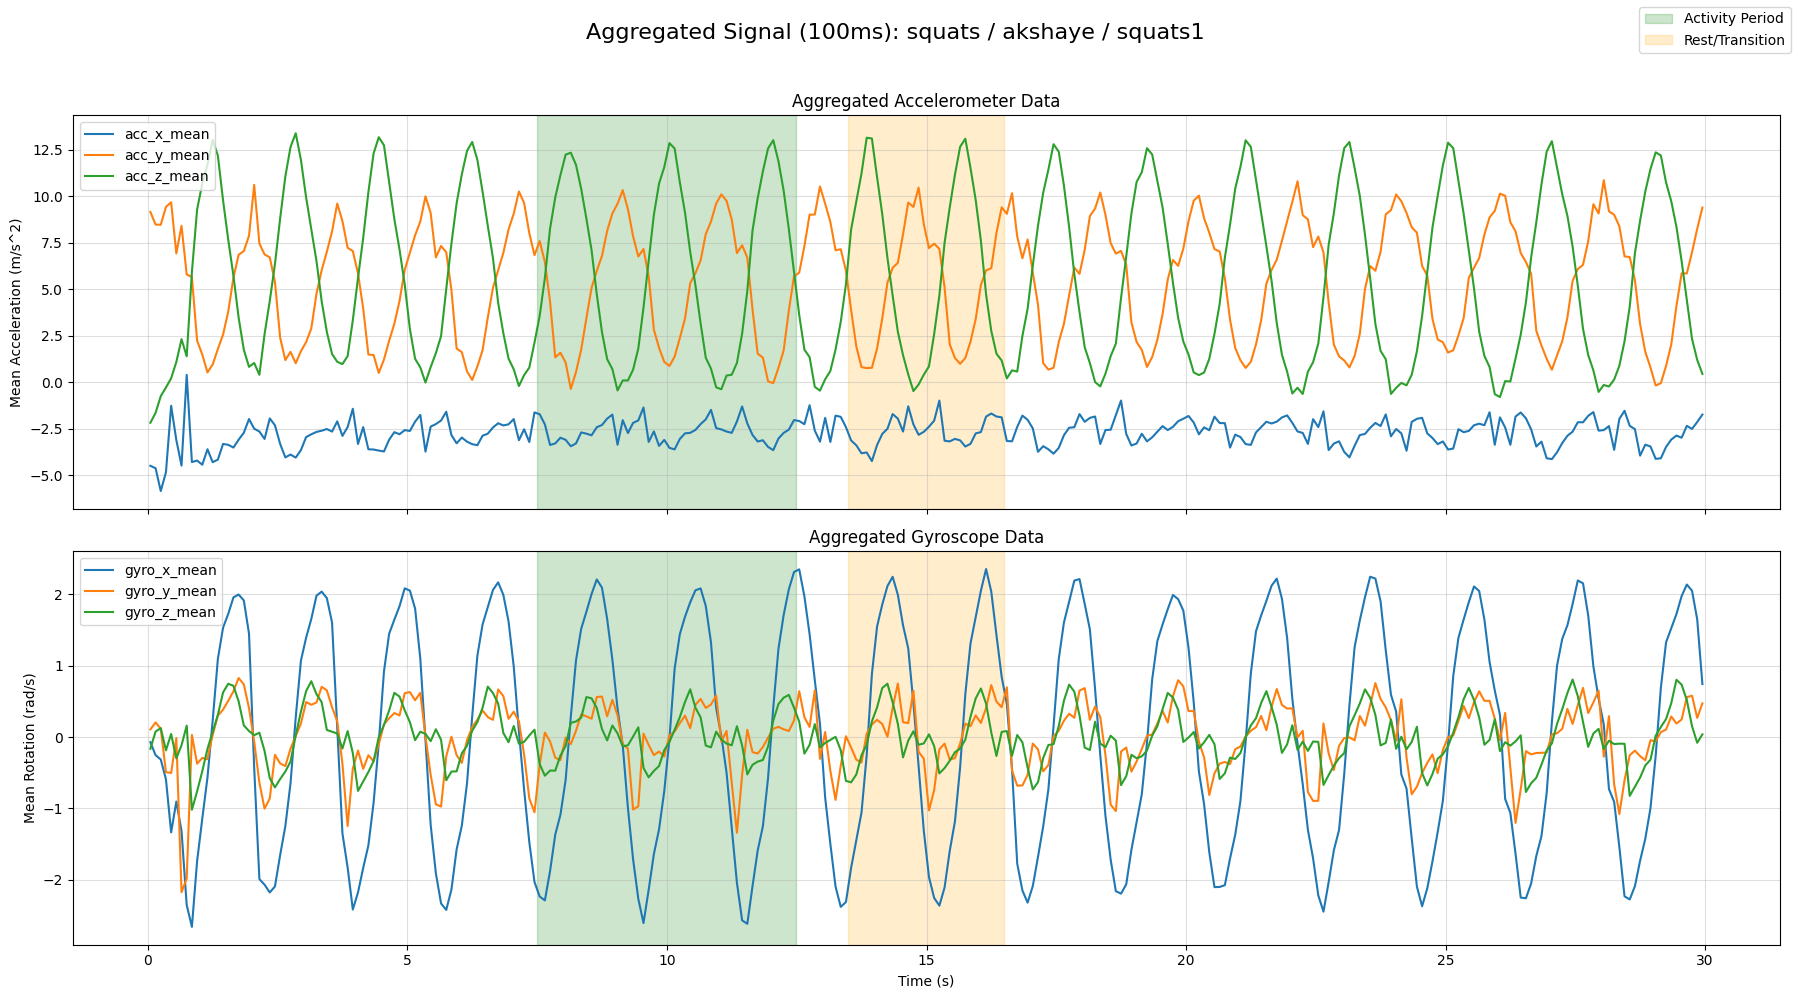

In [5]:
def plot_temporal_signal(df, title="Aggregated Temporal Sensor Data"):
    """
    This function plots the key aggregated sensor features from a temporal dataframe,
    allowing for visual inspection of the resampled signal.
    """
    # First, check if the dataframe has any data before trying to plot.
    if df is None or df.empty:
        print("The provided DataFrame is empty. Cannot create a plot.")
        return

    # Define which aggregated columns we want to visualize.
    plot_accel = ['acc_x_mean', 'acc_y_mean', 'acc_z_mean']
    plot_gyro = ['gyro_x_mean', 'gyro_y_mean', 'gyro_z_mean']

    # Set up the plot with two subplots, one for each sensor type.
    fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True)
    fig.suptitle(title, fontsize=16)

    # Plot the aggregated accelerometer data.
    axes[0].plot(df['time_center'], df[plot_accel])
    axes[0].set_ylabel('Mean Acceleration (m/s^2)')
    axes[0].legend(plot_accel)
    axes[0].set_title('Aggregated Accelerometer Data')
    axes[0].grid(True, alpha=0.4)

    # Plot the aggregated gyroscope data.
    axes[1].plot(df['time_center'], df[plot_gyro])
    axes[1].set_ylabel('Mean Rotation (rad/s)')
    axes[1].legend(plot_gyro)
    axes[1].set_title('Aggregated Gyroscope Data')
    axes[1].grid(True, alpha=0.4)

    # --- Annotation Example ---
    # This section demonstrates how to highlight specific regions of interest.
    duration = df['time_center'].max()
    if duration > 10:
        # Highlight a 5-second window to represent an "activity" period.
        activity_start = duration * 0.25
        activity_end = activity_start + 5
        axes[0].axvspan(activity_start, activity_end, color='green', alpha=0.2, label='Activity Period')
        axes[1].axvspan(activity_start, activity_end, color='green', alpha=0.2)
        
        # Highlight a 3-second window to represent a "rest" or "transition" period.
        if duration > activity_end + 4:
            rest_start = activity_end + 1
            rest_end = rest_start + 3
            axes[0].axvspan(rest_start, rest_end, color='orange', alpha=0.2, label='Rest/Transition')
            axes[1].axvspan(rest_start, rest_end, color='orange', alpha=0.2)
    
    # Add a legend for the annotated regions.
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right')

    plt.xlabel('Time (s)')
    plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout to make room for the main title.
    plt.show()

# --- Main Execution Block ---
# We will now visualize the aggregated data to see how it looks.
# We'll use the 100ms table for this example visualization.
df_100ms = temporal_tables.get(100)

# Ensure the 100ms table exists before trying to plot it.
if df_100ms is not None:
    # For a clean plot, we select just the first recording from the table.
    sample_recording_id = df_100ms['recording_id'].iloc[0]
    sample_df_100ms = df_100ms[df_100ms['recording_id'] == sample_recording_id]
    
    # Create a descriptive title for the plot using the data's metadata.
    plot_title = (f"Aggregated Signal (100ms): {sample_df_100ms['exercise'].iloc[0]} / "
                  f"{sample_df_100ms['participant'].iloc[0]} / "
                  f"{sample_df_100ms['dataset'].iloc[0]}")
                  
    # Call the plotting function with the sample data and title.
    plot_temporal_signal(sample_df_100ms, title=plot_title)
else:
    print("The 100ms temporal table is not available for plotting.")

# Outier Detection and missing Values

In [6]:
# Import required libraries for outlier detection
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

class OutlierDetection:
    """
    Comprehensive outlier detection class implementing multiple methods
    """
    
    def chauvenet_criterion(self, data, column, threshold=2):
        """
        Chauvenet's criterion for outlier detection
        """
        mean_val = data[column].mean()
        std_val = data[column].std()
        
        # Calculate z-scores
        z_scores = np.abs((data[column] - mean_val) / std_val)
        
        # Mark outliers based on threshold
        outliers = z_scores > threshold
        
        print(f"Chauvenet's Criterion: Found {outliers.sum()} outliers in {column}")
        return outliers
    
    def mixture_model_detection(self, data, columns, n_components=2):
        """
        Gaussian Mixture Model for outlier detection
        """
        # Prepare data
        X = data[columns].values
        
        # Fit Gaussian Mixture Model
        gmm = GaussianMixture(n_components=n_components, random_state=42)
        gmm.fit(X)
        
        # Calculate probabilities and identify outliers
        probabilities = gmm.score_samples(X)
        threshold = np.percentile(probabilities, 5)  # Bottom 5% as outliers
        
        outliers = probabilities < threshold
        
        print(f"Mixture Model: Found {outliers.sum()} outliers")
        return outliers
    
    def local_outlier_factor_detection(self, data, columns, n_neighbors=20):
        """
        Local Outlier Factor for outlier detection
        """
        X = data[columns].values
        
        # Apply LOF
        lof = LocalOutlierFactor(n_neighbors=n_neighbors, contamination='auto')
        outliers = lof.fit_predict(X) == -1
        
        print(f"Local Outlier Factor: Found {outliers.sum()} outliers")
        return outliers
    
    def isolation_forest_detection(self, data, columns, contamination=0.1):
        """
        Isolation Forest for outlier detection
        """
        X = data[columns].values
        
        # Apply Isolation Forest
        iso_forest = IsolationForest(contamination=contamination, random_state=42)
        outliers = iso_forest.fit_predict(X) == -1
        
        print(f"Isolation Forest: Found {outliers.sum()} outliers")
        return outliers
    
    def kalman_filter_smoothing(self, data, column):
        """
        Simple Kalman filter implementation for outlier replacement
        """
        from filterpy.kalman import KalmanFilter
        
        # Initialize Kalman filter
        kf = KalmanFilter(dim_x=2, dim_z=1)
        
        # State transition matrix
        kf.F = np.array([[1., 1.],
                         [0., 1.]])
        
        # Measurement function
        kf.H = np.array([[1., 0.]])
        
        # Measurement noise
        kf.R *= 0.05
        
        # Process noise
        kf.Q *= 0.02
        
        # Apply filter
        filtered_values = []
        for value in data[column].values:
            if not np.isnan(value):
                kf.predict()
                kf.update(value)
                filtered_values.append(kf.x[0, 0])
            else:
                kf.predict()
                filtered_values.append(kf.x[0, 0])
        
        return np.array(filtered_values)

def handle_missing_values(data, columns, method='linear'):
    """
    Handle missing values using various interpolation methods
    """
    data_clean = data.copy()
    
    for col in columns:
        missing_count = data_clean[col].isnull().sum()
        if missing_count > 0:
            print(f"Handling {missing_count} missing values in {col}")
            
            if method == 'linear':
                data_clean[col] = data_clean[col].interpolate(method='linear')
            elif method == 'forward_fill':
                data_clean[col] = data_clean[col].fillna(method='ffill')
            elif method == 'backward_fill':
                data_clean[col] = data_clean[col].fillna(method='bfill')
            elif method == 'mean':
                data_clean[col] = data_clean[col].fillna(data_clean[col].mean())
            
            # Handle any remaining NaN values
            data_clean[col] = data_clean[col].fillna(method='ffill').fillna(method='bfill')
    
    return data_clean

def compare_outlier_methods(data, sensor_columns):
    """
    Compare different outlier detection methods
    """
    detector = OutlierDetection()
    results = {}
    
    print("="*60)
    print("OUTLIER DETECTION COMPARISON")
    print("="*60)
    
    # Test each method
    for col in sensor_columns[:3]:  # Test on first 3 sensor columns
        print(f"\nAnalyzing column: {col}")
        print("-" * 30)
        
        # Chauvenet's Criterion
        results[f'{col}_chauvenet'] = detector.chauvenet_criterion(data, col)
        
        # Mixture Model (using single column)
        results[f'{col}_mixture'] = detector.mixture_model_detection(data, [col])
        
        # LOF (using single column)
        results[f'{col}_lof'] = detector.local_outlier_factor_detection(data, [col])
        
        # Isolation Forest (using single column)
        results[f'{col}_isolation'] = detector.isolation_forest_detection(data, [col])
    
    return results

# --- Main Execution ---
# Use the complete 100ms temporal dataset from previous processing
if temporal_tables.get(100) is not None:
    sample_data = temporal_tables[100].copy()  # Use the complete 100ms dataset
    
    # Define sensor columns for analysis (focusing on mean aggregated values)
    sensor_cols = [col for col in sample_data.columns if 
                   any(sensor in col for sensor in ['acc_', 'gyro_', 'lin_acc_']) and 
                   col.endswith('_mean')]
    
    print(f"Analyzing complete 100ms temporal dataset:")
    print(f"Dataset shape: {sample_data.shape}")
    print(f"Number of sensor columns: {len(sensor_cols)}")
    print(f"Sensor columns: {sensor_cols}")
    print(f"Number of recordings: {sample_data['recording_id'].nunique()}")
    print(f"Exercises included: {sample_data['exercise'].unique()}")
    
    # Handle missing values first
    print("\n" + "="*60)
    print("MISSING VALUES HANDLING")
    print("="*60)
    
    sample_data_clean = handle_missing_values(sample_data, sensor_cols, method='linear')
    
    # Compare outlier detection methods
    outlier_results = compare_outlier_methods(sample_data_clean, sensor_cols)
    
    # Apply Kalman filter to a sample column
    if len(sensor_cols) > 0:
        detector = OutlierDetection()
        col_to_filter = sensor_cols[0]
        
        print(f"\n" + "="*60)
        print(f"KALMAN FILTER APPLICATION ON {col_to_filter}")
        print("="*60)
        
        try:
            # Note: This requires filterpy library
            # Install with: pip install filterpy
            filtered_values = detector.kalman_filter_smoothing(sample_data_clean, col_to_filter)
            print(f"Successfully applied Kalman filter to {col_to_filter}")
            
            # Add filtered column to dataframe
            sample_data_clean[f'{col_to_filter}_kalman'] = filtered_values
            
        except ImportError:
            print("Kalman filter requires 'filterpy' library. Install with: pip install filterpy")
        except Exception as e:
            print(f"Error applying Kalman filter: {e}")

else:
    print("No 100ms temporal data available for outlier detection analysis")

Analyzing complete 100ms temporal dataset:
Dataset shape: (7219, 78)
Number of sensor columns: 9
Sensor columns: ['acc_x_mean', 'acc_y_mean', 'acc_z_mean', 'gyro_x_mean', 'gyro_y_mean', 'gyro_z_mean', 'lin_acc_x_mean', 'lin_acc_y_mean', 'lin_acc_z_mean']
Number of recordings: 24
Exercises included: ['squats' 'crunches' 'jumping_jacks' 'plank' 'burpees']

MISSING VALUES HANDLING
OUTLIER DETECTION COMPARISON

Analyzing column: acc_x_mean
------------------------------
Chauvenet's Criterion: Found 170 outliers in acc_x_mean
Mixture Model: Found 342 outliers
Local Outlier Factor: Found 154 outliers
Isolation Forest: Found 721 outliers

Analyzing column: acc_y_mean
------------------------------
Chauvenet's Criterion: Found 230 outliers in acc_y_mean
Mixture Model: Found 361 outliers
Local Outlier Factor: Found 87 outliers
Isolation Forest: Found 722 outliers

Analyzing column: acc_z_mean
------------------------------
Chauvenet's Criterion: Found 22 outliers in acc_z_mean
Mixture Model: Fo

In [7]:
import sys

!{sys.executable} -m pip install filterpy


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip3.13 install --upgrade pip


In [8]:
temporal_tables[100].head()

,exercise,participant,dataset,recording_id,timestep_ms,time_center,acc_x_mean,acc_x_std,acc_x_min,acc_x_max,...,Linear Acceleration x (m/s^2)_min,Linear Acceleration x (m/s^2)_max,Linear Acceleration y (m/s^2)_mean,Linear Acceleration y (m/s^2)_std,Linear Acceleration y (m/s^2)_min,Linear Acceleration y (m/s^2)_max,Linear Acceleration z (m/s^2)_mean,Linear Acceleration z (m/s^2)_std,Linear Acceleration z (m/s^2)_min,Linear Acceleration z (m/s^2)_max
0,squats,akshaye,squats1,squats_akshaye_squats1,100,0.046923,-4.496859,0.698092,-5.470374,-3.648214,...,-5.692915,0.0,-1.235603,0.977314,-3.01504,0.0,1.445873,2.01495,-0.489951,5.782326
1,squats,akshaye,squats1,squats_akshaye_squats1,100,0.146923,-4.625827,0.668822,-6.172564,-3.708538,...,-5.692915,0.0,-1.235603,0.977314,-3.01504,0.0,1.445873,2.01495,-0.489951,5.782326
2,squats,akshaye,squats1,squats_akshaye_squats1,100,0.246923,-5.853390,0.220267,-6.139184,-5.573660,...,-5.692915,0.0,-1.235603,0.977314,-3.01504,0.0,1.445873,2.01495,-0.489951,5.782326
3,squats,akshaye,squats1,squats_akshaye_squats1,100,0.346923,-4.846273,0.874655,-5.803581,-3.234923,...,-5.692915,0.0,-1.235603,0.977314,-3.01504,0.0,1.445873,2.01495,-0.489951,5.782326
4,squats,akshaye,squats1,squats_akshaye_squats1,100,0.446923,-1.270101,0.888935,-3.018623,-0.291294,...,-5.692915,0.0,-1.235603,0.977314,-3.01504,0.0,1.445873,2.01495,-0.489951,5.782326


columns-
[
    'exercise', 'participant', 'dataset', 'recording_id', 'timestep_ms', 'time_center',
    'acc_x_mean', 'acc_x_std', 'acc_x_min', 'acc_x_max', 'acc_y_mean', 'acc_y_std',
    'acc_y_min', 'acc_y_max', 'acc_z_mean', 'acc_z_std', 'acc_z_min', 'acc_z_max',
    'gyro_x_mean', 'gyro_x_std', 'gyro_x_min', 'gyro_x_max', 'gyro_y_mean', 'gyro_y_std',
    'gyro_y_min', 'gyro_y_max', 'gyro_z_mean', 'gyro_z_std', 'gyro_z_min', 'gyro_z_max',
    'lin_acc_x_mean', 'lin_acc_x_std', 'lin_acc_x_min', 'lin_acc_x_max', 'lin_acc_y_mean',
    'lin_acc_y_std', 'lin_acc_y_min', 'lin_acc_y_max', 'lin_acc_z_mean', 'lin_acc_z_std',
    'lin_acc_z_min', 'lin_acc_z_max', 'Acceleration x (m/s^2)_mean', 'Acceleration x (m/s^2)_std',
    'Acceleration x (m/s^2)_min', 'Acceleration x (m/s^2)_max', 'Acceleration y (m/s^2)_mean',
    'Acceleration y (m/s^2)_std', 'Acceleration y (m/s^2)_min', 'Acceleration y (m/s^2)_max',
    'Acceleration z (m/s^2)_mean', 'Acceleration z (m/s^2)_std', 'Acceleration z (m/s^2)_min',
    'Acceleration z (m/s^2)_max', 'Gyroscope x (rad/s)_mean', 'Gyroscope x (rad/s)_std',
    'Gyroscope x (rad/s)_min', 'Gyroscope x (rad/s)_max', 'Gyroscope y (rad/s)_mean',
    'Gyroscope y (rad/s)_std', 'Gyroscope y (rad/s)_min', 'Gyroscope y (rad/s)_max',
    'Gyroscope z (rad/s)_mean', 'Gyroscope z (rad/s)_std', 'Gyroscope z (rad/s)_min',
    'Gyroscope z (rad/s)_max', 'Linear Acceleration x (m/s^2)_mean', 'Linear Acceleration x (m/s^2)_std',
    'Linear Acceleration x (m/s^2)_min', 'Linear Acceleration x (m/s^2)_max', 'Linear Acceleration y (m/s^2)_mean',
    'Linear Acceleration y (m/s^2)_std', 'Linear Acceleration y (m/s^2)_min', 'Linear Acceleration y (m/s^2)_max',
    'Linear Acceleration z (m/s^2)_mean', 'Linear Acceleration z (m/s^2)_std', 'Linear Acceleration z (m/s^2)_min',
    'Linear Acceleration z (m/s^2)_max'
]

### Kalman Filtering for outier detection and removal

KALMAN FILTER OUTLIER DETECTION AND REPLACEMENT

Processing column: acc_x_mean
----------------------------------------
Total data points: 300
Outliers detected: 156
Outlier percentage: 52.00%


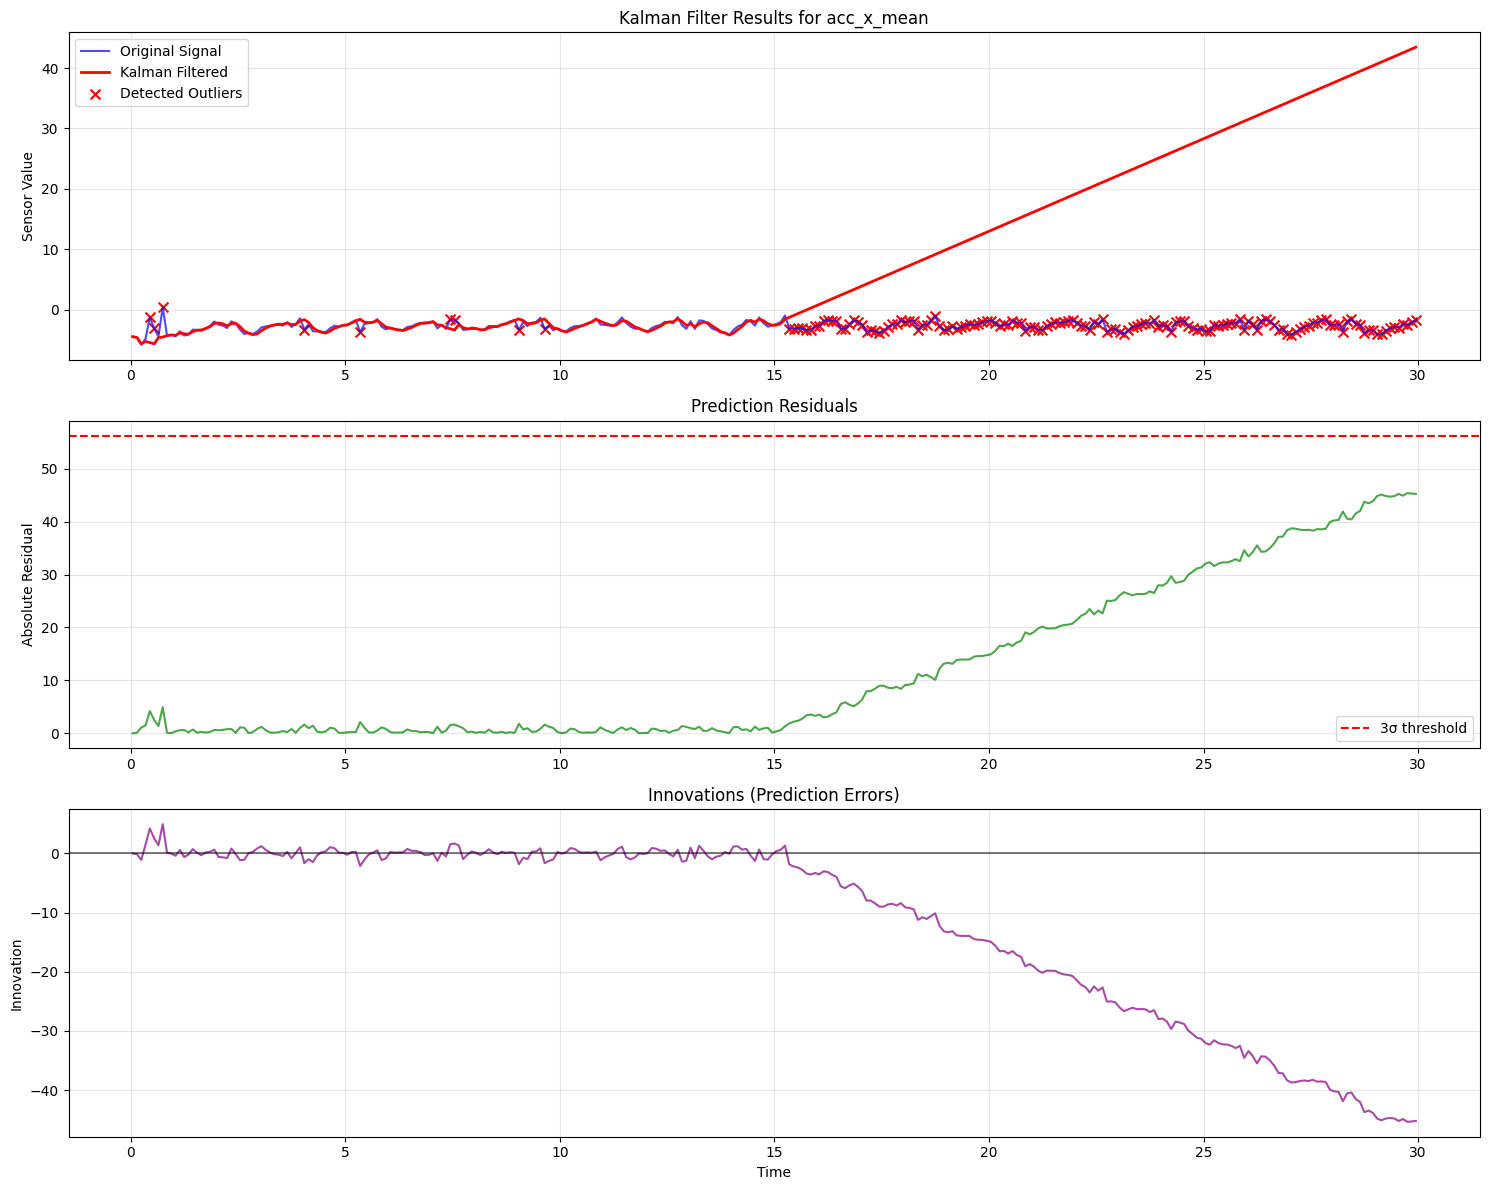


Processing column: acc_y_mean
----------------------------------------
Total data points: 300
Outliers detected: 295
Outlier percentage: 98.33%


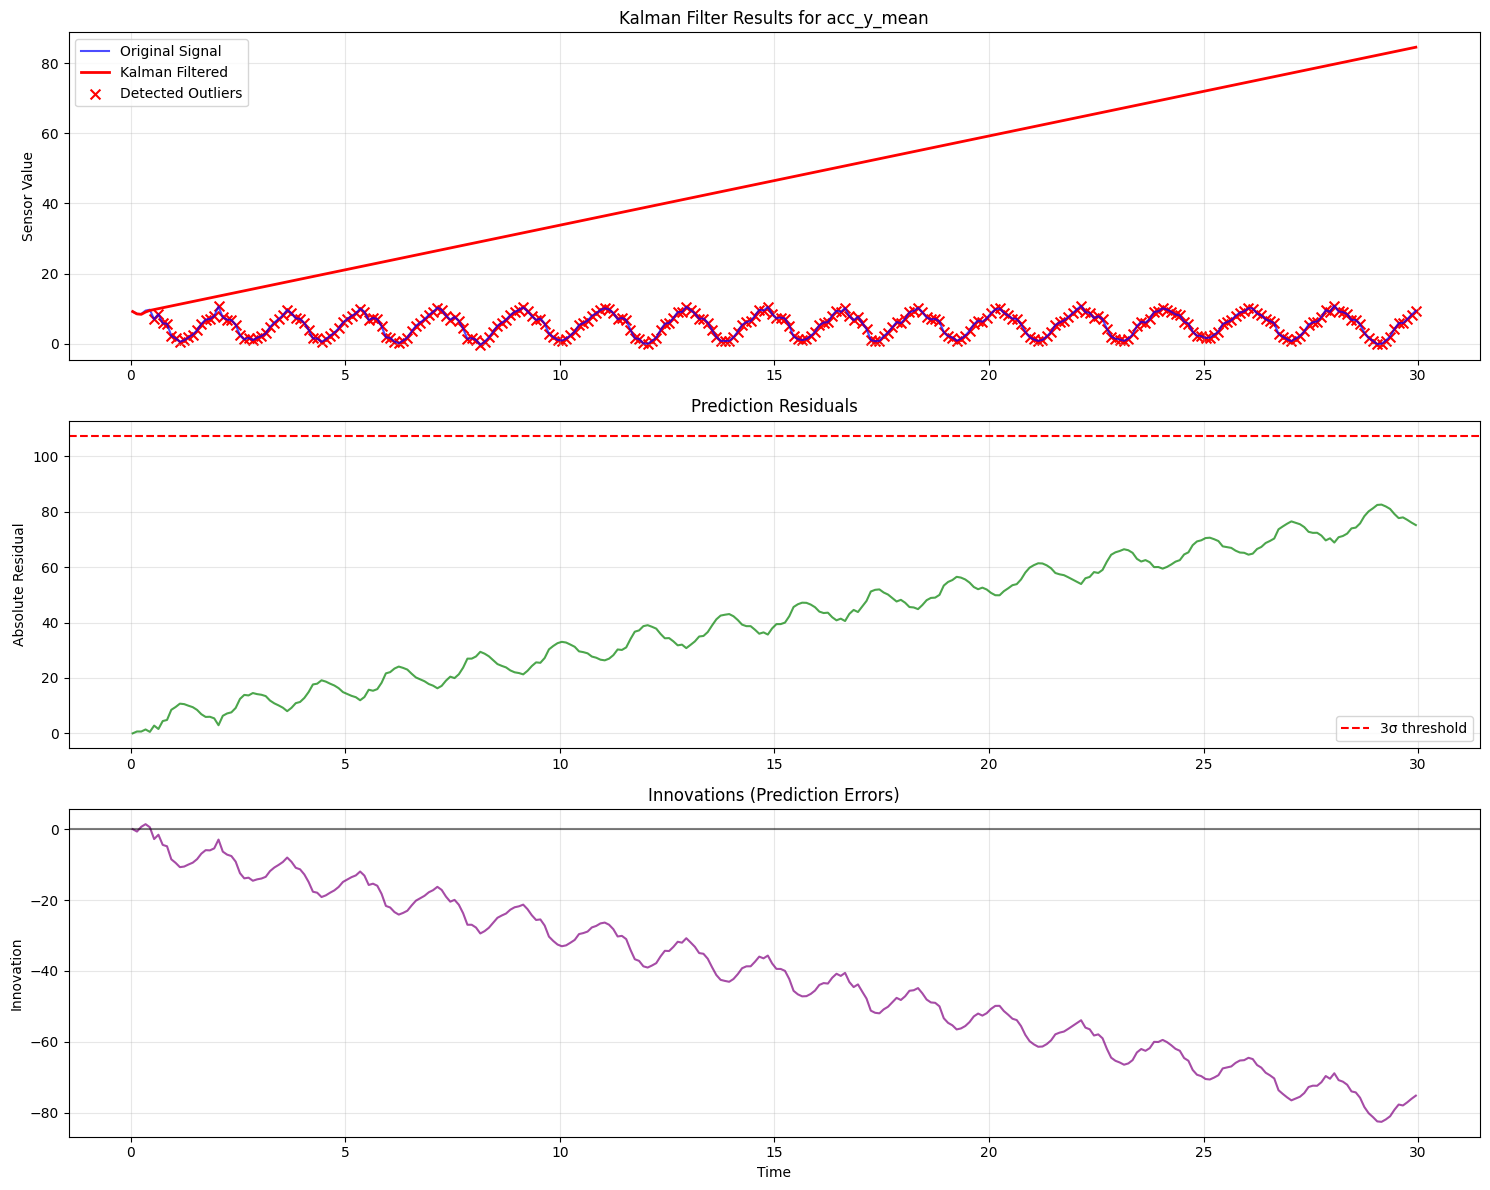


Processing column: acc_z_mean
----------------------------------------
Total data points: 300
Outliers detected: 279
Outlier percentage: 93.00%


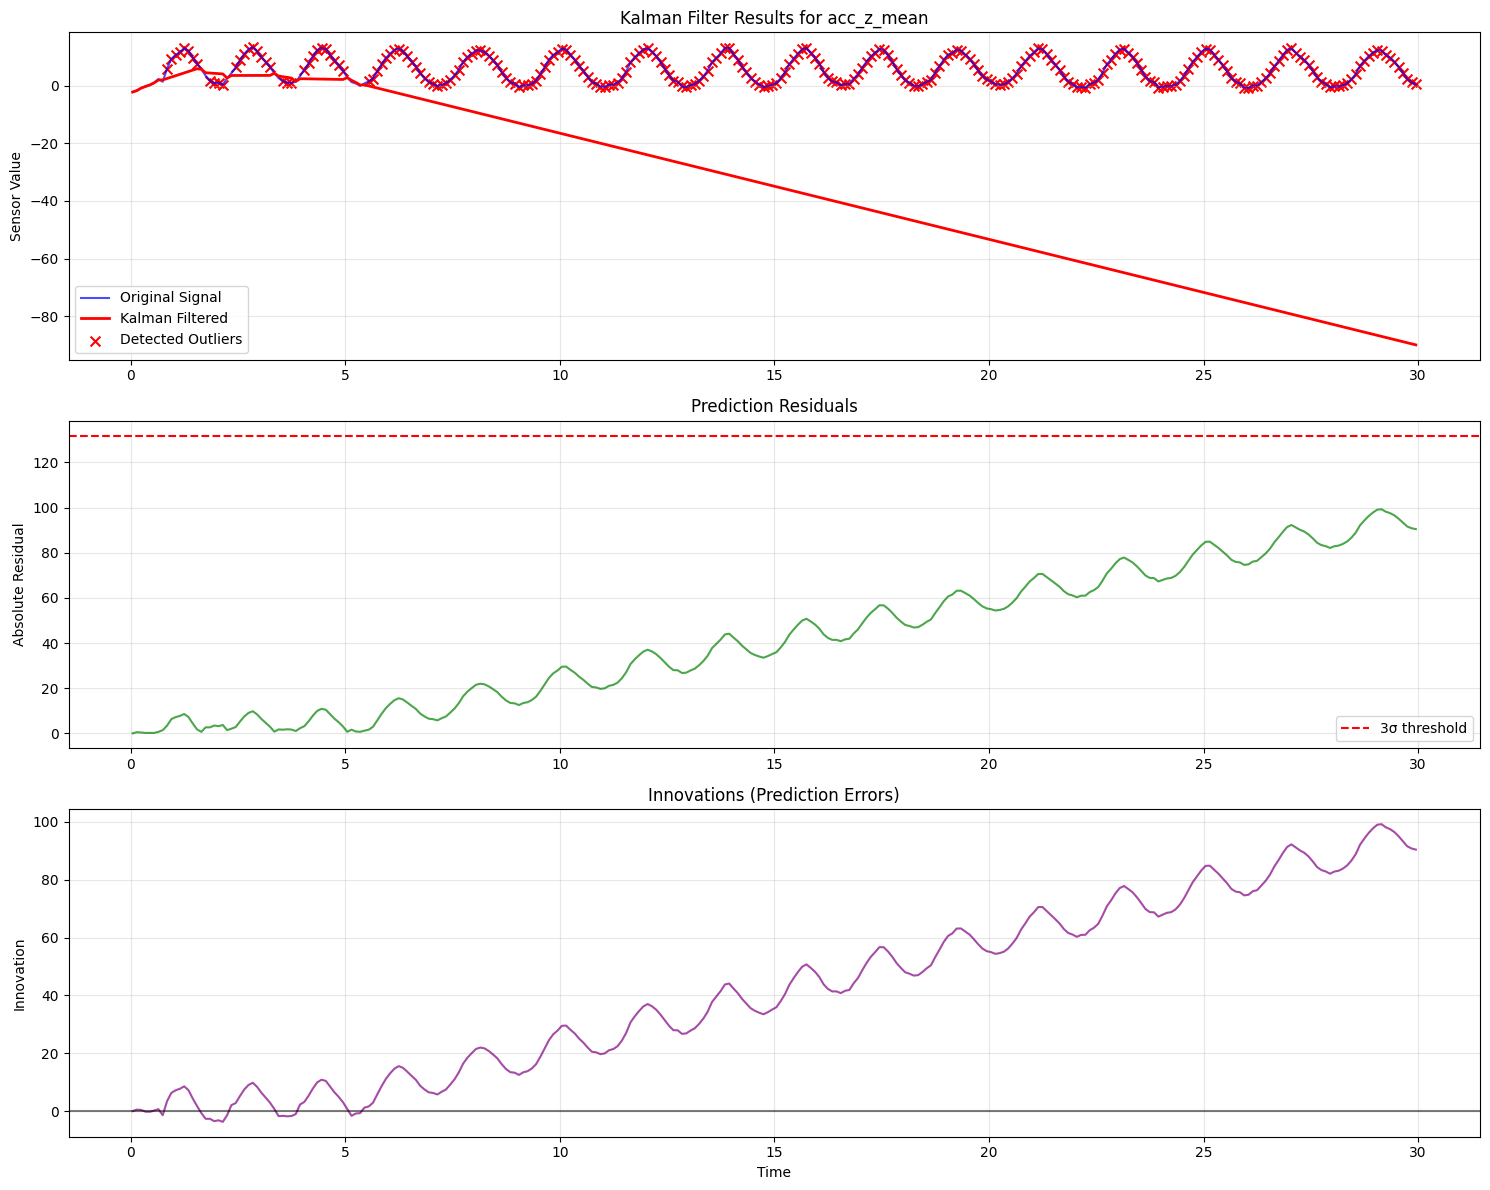


KALMAN FILTER SUMMARY
Columns processed: 3
Total data points analyzed: 900
Total outliers detected and replaced: 730
Overall outlier rate: 81.11%

Per-column breakdown:
  acc_x_mean: 156 outliers (52.00%)
  acc_y_mean: 295 outliers (98.33%)
  acc_z_mean: 279 outliers (93.00%)


In [9]:
# ===================================================================
# KALMAN FILTER IMPLEMENTATION FOR OUTLIER DETECTION AND REPLACEMENT
# ===================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from filterpy.kalman import KalmanFilter
from filterpy.common import Q_discrete_white_noise

class KalmanOutlierDetector:
    """
    Kalman Filter implementation for sensor data outlier detection and replacement
    """
    
    def __init__(self, process_variance=0.01, measurement_variance=0.1, outlier_threshold=3.0):
        """
        Initialize Kalman filter parameters
        
        Args:
            process_variance: How much we expect the true signal to vary
            measurement_variance: How noisy we expect our measurements to be
            outlier_threshold: Standard deviations for outlier detection
        """
        self.process_variance = process_variance
        self.measurement_variance = measurement_variance
        self.outlier_threshold = outlier_threshold
        
    def setup_kalman_filter(self):
        """
        Configure the Kalman filter for 1D sensor data
        """
        # Create filter with 2 state variables (position and velocity)
        kf = KalmanFilter(dim_x=2, dim_z=1)
        
        # State transition matrix (constant velocity model)
        dt = 1.0  # time step
        kf.F = np.array([[1., dt],
                         [0., 1.]])
        
        # Measurement function (we only observe position)
        kf.H = np.array([[1., 0.]])
        
        # Measurement uncertainty
        kf.R *= self.measurement_variance
        
        # Process noise
        kf.Q = Q_discrete_white_noise(dim=2, dt=dt, var=self.process_variance)
        
        # Initial uncertainty
        kf.P *= 100
        
        return kf
    
    def detect_and_replace_outliers(self, data, column_name):
        """
        Apply Kalman filter to detect and replace outliers
        
        Args:
            data: DataFrame containing the sensor data
            column_name: Name of the column to filter
            
        Returns:
            Dictionary containing results
        """
        values = data[column_name].values
        kf = self.setup_kalman_filter()
        
        # Initialize with first valid measurement
        first_valid_idx = 0
        while first_valid_idx < len(values) and np.isnan(values[first_valid_idx]):
            first_valid_idx += 1
            
        if first_valid_idx >= len(values):
            raise ValueError("No valid measurements found")
            
        kf.x = np.array([[values[first_valid_idx]], [0.]])
        
        # Storage for results
        filtered_values = []
        predicted_values = []
        residuals = []
        outlier_flags = []
        innovations = []
        
        for i, measurement in enumerate(values):
            # Prediction step
            kf.predict()
            predicted_value = kf.x[0, 0]
            predicted_values.append(predicted_value)
            
            if not np.isnan(measurement):
                # Calculate innovation (prediction error)
                innovation = measurement - predicted_value
                innovation_std = np.sqrt(kf.S[0, 0])
                
                # Detect outlier based on innovation
                is_outlier = abs(innovation) > (self.outlier_threshold * innovation_std)
                
                if not is_outlier:
                    # Normal measurement - update filter
                    kf.update(measurement)
                    filtered_values.append(kf.x[0, 0])
                    outlier_flags.append(False)
                else:
                    # Outlier detected - use prediction instead
                    filtered_values.append(predicted_value)
                    outlier_flags.append(True)
                
                innovations.append(innovation)
                residuals.append(abs(innovation))
            else:
                # Missing measurement - use prediction
                filtered_values.append(predicted_value)
                outlier_flags.append(False)
                innovations.append(0)
                residuals.append(0)
        
        return {
            'original': values,
            'filtered': np.array(filtered_values),
            'predicted': np.array(predicted_values),
            'outlier_flags': np.array(outlier_flags),
            'residuals': np.array(residuals),
            'innovations': np.array(innovations),
            'outlier_count': sum(outlier_flags)
        }
    
    def visualize_results(self, results, column_name, time_values=None):
        """
        Create visualization of Kalman filter results
        """
        if time_values is None:
            time_values = np.arange(len(results['original']))
        
        fig, axes = plt.subplots(3, 1, figsize=(15, 12))
        
        # Plot 1: Original vs Filtered signal
        axes[0].plot(time_values, results['original'], 'b-', alpha=0.7, label='Original Signal')
        axes[0].plot(time_values, results['filtered'], 'r-', linewidth=2, label='Kalman Filtered')
        
        # Highlight outliers
        outlier_indices = np.where(results['outlier_flags'])[0]
        if len(outlier_indices) > 0:
            axes[0].scatter(time_values[outlier_indices], 
                          results['original'][outlier_indices], 
                          color='red', s=50, marker='x', label='Detected Outliers')
        
        axes[0].set_title(f'Kalman Filter Results for {column_name}')
        axes[0].set_ylabel('Sensor Value')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Plot 2: Residuals
        axes[1].plot(time_values, results['residuals'], 'g-', alpha=0.7)
        axes[1].axhline(y=np.mean(results['residuals']) + 3*np.std(results['residuals']), 
                       color='r', linestyle='--', label='3σ threshold')
        axes[1].set_title('Prediction Residuals')
        axes[1].set_ylabel('Absolute Residual')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        # Plot 3: Innovations
        axes[2].plot(time_values, results['innovations'], 'purple', alpha=0.7)
        axes[2].axhline(y=0, color='black', linestyle='-', alpha=0.5)
        axes[2].set_title('Innovations (Prediction Errors)')
        axes[2].set_xlabel('Time')
        axes[2].set_ylabel('Innovation')
        axes[2].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

# ===================================================================
# MAIN EXECUTION: APPLY KALMAN FILTER
# ===================================================================

if temporal_tables.get(100) is not None and 'sample_data_clean' in locals():
    
    print("="*70)
    print("KALMAN FILTER OUTLIER DETECTION AND REPLACEMENT")
    print("="*70)
    
    # Initialize Kalman filter detector
    kalman_detector = KalmanOutlierDetector(
        process_variance=0.01,      # How much we expect the signal to change
        measurement_variance=0.1,   # Expected measurement noise
        outlier_threshold=3.0       # 3-sigma rule for outlier detection
    )
    
    # Select sensor columns to analyze
    sensor_cols = [col for col in sample_data_clean.columns if 
                   any(sensor in col for sensor in ['acc_', 'gyro_', 'lin_acc_']) and 
                   col.endswith('_mean')]
    
    # Apply Kalman filter to first few sensor columns
    kalman_results = {}
    cols_to_analyze = sensor_cols[:3]  # Analyze first 3 columns
    
    for col in cols_to_analyze:
        print(f"\nProcessing column: {col}")
        print("-" * 40)
        
        try:
            # Select data from one recording for cleaner visualization
            sample_recording = sample_data_clean['recording_id'].iloc[0]
            single_recording_data = sample_data_clean[
                sample_data_clean['recording_id'] == sample_recording
            ].copy()
            
            # Apply Kalman filter
            results = kalman_detector.detect_and_replace_outliers(single_recording_data, col)
            kalman_results[col] = results
            
            print(f"Total data points: {len(results['original'])}")
            print(f"Outliers detected: {results['outlier_count']}")
            print(f"Outlier percentage: {results['outlier_count']/len(results['original'])*100:.2f}%")
            
            # Add filtered values back to dataframe
            single_recording_data[f'{col}_kalman'] = results['filtered']
            
            # Create visualization
            time_values = single_recording_data['time_center'].values
            kalman_detector.visualize_results(results, col, time_values)
            
        except Exception as e:
            print(f"Error processing {col}: {e}")
    
    # Summary statistics
    print(f"\n" + "="*70)
    print("KALMAN FILTER SUMMARY")
    print("="*70)
    
    total_outliers = sum([results['outlier_count'] for results in kalman_results.values()])
    total_points = sum([len(results['original']) for results in kalman_results.values()])
    
    print(f"Columns processed: {len(kalman_results)}")
    print(f"Total data points analyzed: {total_points}")
    print(f"Total outliers detected and replaced: {total_outliers}")
    print(f"Overall outlier rate: {total_outliers/total_points*100:.2f}%")
    
    print(f"\nPer-column breakdown:")
    for col, results in kalman_results.items():
        outlier_rate = results['outlier_count']/len(results['original'])*100
        print(f"  {col}: {results['outlier_count']} outliers ({outlier_rate:.2f}%)")

else:
    print("Error: Required data not available. Please run previous cells first.")

COMPREHENSIVE KALMAN FILTER ANALYSIS
Working with dataset shape: (7219, 78)
Number of recordings: 24
Analyzing recording: squats_akshaye_squats1
Sensor attributes to test: 9
Data points per attribute: 300
----------------------------------------------------------------------

Testing configuration: Conservative
Parameters: {'process_var': 0.01, 'meas_var': 0.1, 'threshold': 4.0, 'adaptive': False}
  Average outlier rate: 0.00%
  Range: 0.00% - 0.00%

Testing configuration: Moderate
Parameters: {'process_var': 0.02, 'meas_var': 0.5, 'threshold': 3.0, 'adaptive': True}
  Average outlier rate: 52.44%
  Range: 12.33% - 97.33%

Testing configuration: Aggressive
Parameters: {'process_var': 0.03, 'meas_var': 1.0, 'threshold': 2.0, 'adaptive': True}
  Average outlier rate: 55.44%
  Range: 12.67% - 97.33%

Analysis completed!
Results shape: (27, 10)

Configuration Performance Summary:
                mean    std
Configuration              
Aggressive     55.44  29.68
Conservative    0.00   0.00

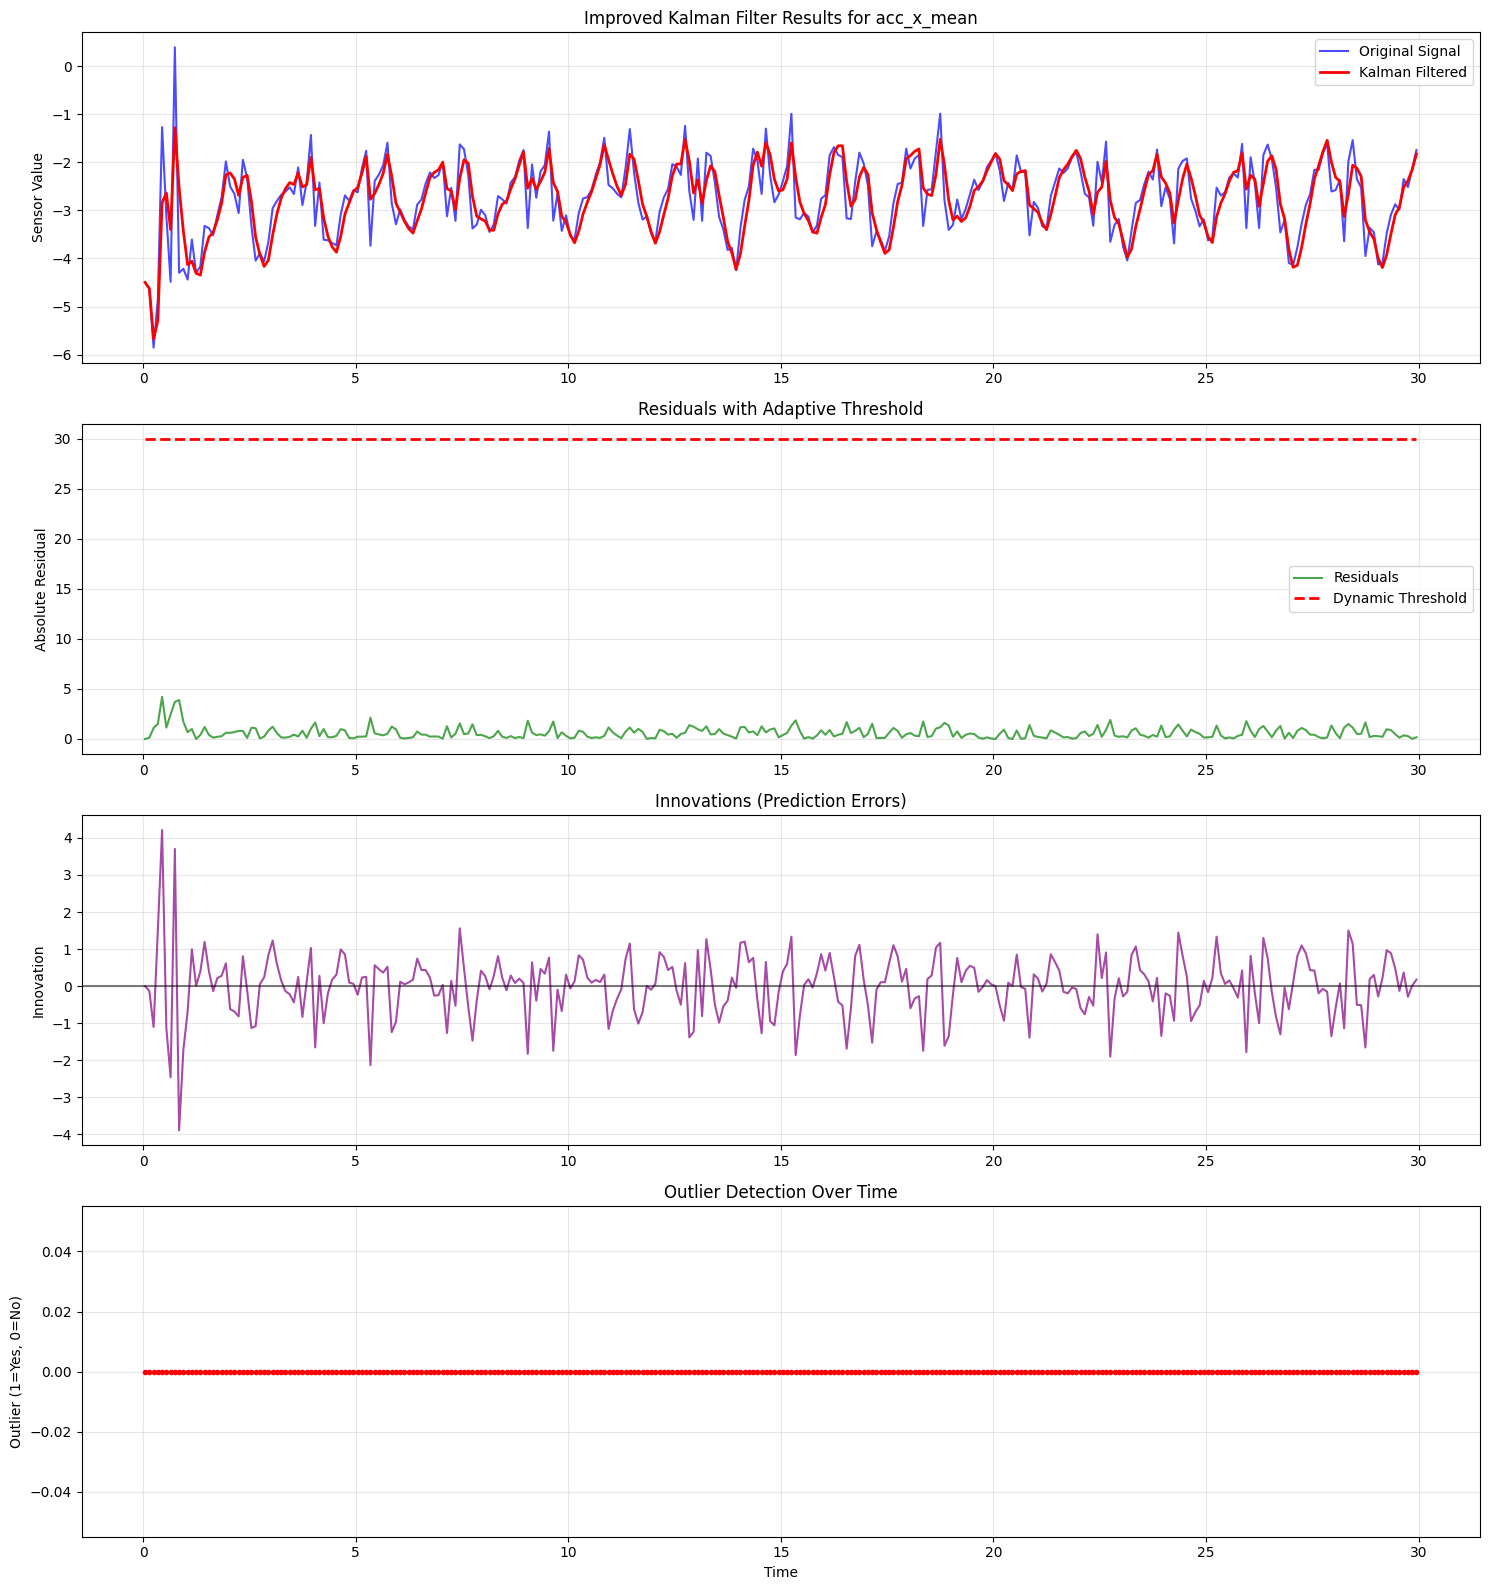


Kalman filter analysis completed successfully!


In [10]:
# ===================================================================
# IMPROVED KALMAN FILTER WITH ADAPTIVE PARAMETERS
# ===================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from filterpy.kalman import KalmanFilter
from filterpy.common import Q_discrete_white_noise

class ImprovedKalmanOutlierDetector:
    """
    Enhanced Kalman Filter with adaptive parameters for better outlier detection
    """
    
    def __init__(self, process_variance=0.02, measurement_variance=0.5, 
                 outlier_threshold=3.0, adaptive_threshold=True, window_size=50):
        """
        Initialize improved Kalman filter parameters
        
        Args:
            process_variance: How much we expect the true signal to vary (increased)
            measurement_variance: How noisy we expect measurements to be (increased)
            outlier_threshold: Standard deviations for outlier detection
            adaptive_threshold: Use dynamic threshold based on residual statistics
            window_size: Window size for dynamic threshold calculation
        """
        self.process_variance = process_variance
        self.measurement_variance = measurement_variance
        self.outlier_threshold = outlier_threshold
        self.adaptive_threshold = adaptive_threshold
        self.window_size = window_size
        
    def setup_kalman_filter(self):
        """
        Configure the Kalman filter with improved parameters
        """
        kf = KalmanFilter(dim_x=2, dim_z=1)
        
        dt = 1.0
        kf.F = np.array([[1., dt],
                         [0., 1.]])
        
        kf.H = np.array([[1., 0.]])
        
        # Increased measurement uncertainty to trust measurements less
        kf.R *= self.measurement_variance
        
        # Increased process noise to allow more adaptation
        kf.Q = Q_discrete_white_noise(dim=2, dt=dt, var=self.process_variance)
        
        kf.P *= 100
        
        return kf
    
    def calculate_dynamic_threshold(self, residuals, window_idx, k=2.5):
        """
        Calculate dynamic threshold based on local residual statistics
        """
        start_idx = max(0, window_idx - self.window_size)
        end_idx = min(len(residuals), window_idx + 1)
        
        if end_idx - start_idx < 5:  # Minimum window size
            return self.outlier_threshold * np.std(residuals[:window_idx+1]) if window_idx > 0 else 30
        
        window_residuals = residuals[start_idx:end_idx]
        return k * np.std(window_residuals)
    
    def detect_and_replace_outliers_improved(self, data, column_name, segment_size=None):
        """
        Apply improved Kalman filter with adaptive parameters
        
        Args:
            data: DataFrame containing the sensor data
            column_name: Name of the column to filter
            segment_size: If specified, apply filter in segments
            
        Returns:
            Dictionary containing results
        """
        values = data[column_name].values
        
        if segment_size is not None:
            return self._segmented_filtering(values, segment_size)
        else:
            return self._single_pass_filtering(values)
    
    def _single_pass_filtering(self, values):
        """
        Single-pass filtering with adaptive threshold
        """
        kf = self.setup_kalman_filter()
        
        # Initialize with first valid measurement
        first_valid_idx = 0
        while first_valid_idx < len(values) and np.isnan(values[first_valid_idx]):
            first_valid_idx += 1
            
        if first_valid_idx >= len(values):
            raise ValueError("No valid measurements found")
            
        kf.x = np.array([[values[first_valid_idx]], [0.]])
        
        # Storage for results
        filtered_values = []
        predicted_values = []
        residuals = []
        outlier_flags = []
        innovations = []
        thresholds_used = []
        
        for i, measurement in enumerate(values):
            # Prediction step
            kf.predict()
            predicted_value = kf.x[0, 0]
            predicted_values.append(predicted_value)
            
            if not np.isnan(measurement):
                # Calculate innovation
                innovation = measurement - predicted_value
                residual = abs(innovation)
                residuals.append(residual)
                
                # Calculate threshold (adaptive or fixed)
                if self.adaptive_threshold and len(residuals) > 5:
                    threshold = self.calculate_dynamic_threshold(residuals, len(residuals)-1)
                else:
                    # Use signal amplitude-based threshold for early measurements
                    signal_range = np.nanmax(values) - np.nanmin(values)
                    threshold = max(self.outlier_threshold * signal_range * 0.1, 30)
                
                thresholds_used.append(threshold)
                
                # Detect outlier
                is_outlier = residual > threshold
                
                if not is_outlier:
                    # Normal measurement - update filter
                    kf.update(measurement)
                    filtered_values.append(kf.x[0, 0])
                    outlier_flags.append(False)
                else:
                    # Outlier detected - use prediction
                    filtered_values.append(predicted_value)
                    outlier_flags.append(True)
                
                innovations.append(innovation)
            else:
                # Missing measurement
                filtered_values.append(predicted_value)
                outlier_flags.append(False)
                innovations.append(0)
                residuals.append(0)
                thresholds_used.append(0)
        
        return {
            'original': values,
            'filtered': np.array(filtered_values),
            'predicted': np.array(predicted_values),
            'outlier_flags': np.array(outlier_flags),
            'residuals': np.array(residuals),
            'innovations': np.array(innovations),
            'thresholds': np.array(thresholds_used),
            'outlier_count': sum(outlier_flags)
        }
    
    def _segmented_filtering(self, values, segment_size):
        """
        Apply Kalman filter in segments to handle sudden changes better
        """
        n_segments = len(values) // segment_size + (1 if len(values) % segment_size != 0 else 0)
        
        all_filtered = []
        all_outlier_flags = []
        all_residuals = []
        all_innovations = []
        all_thresholds = []
        
        for seg_idx in range(n_segments):
            start_idx = seg_idx * segment_size
            end_idx = min((seg_idx + 1) * segment_size, len(values))
            segment_values = values[start_idx:end_idx]
            
            # Apply filtering to this segment
            segment_results = self._single_pass_filtering(segment_values)
            
            all_filtered.extend(segment_results['filtered'])
            all_outlier_flags.extend(segment_results['outlier_flags'])
            all_residuals.extend(segment_results['residuals'])
            all_innovations.extend(segment_results['innovations'])
            all_thresholds.extend(segment_results['thresholds'])
        
        return {
            'original': values,
            'filtered': np.array(all_filtered),
            'outlier_flags': np.array(all_outlier_flags),
            'residuals': np.array(all_residuals),
            'innovations': np.array(all_innovations),
            'thresholds': np.array(all_thresholds),
            'outlier_count': sum(all_outlier_flags)
        }
    
    def visualize_improved_results(self, results, column_name, time_values=None):
        """
        Enhanced visualization including threshold information
        """
        if time_values is None:
            time_values = np.arange(len(results['original']))
        
        fig, axes = plt.subplots(4, 1, figsize=(15, 16))
        
        # Plot 1: Original vs Filtered signal
        axes[0].plot(time_values, results['original'], 'b-', alpha=0.7, label='Original Signal')
        axes[0].plot(time_values, results['filtered'], 'r-', linewidth=2, label='Kalman Filtered')
        
        outlier_indices = np.where(results['outlier_flags'])[0]
        if len(outlier_indices) > 0:
            axes[0].scatter(time_values[outlier_indices], 
                          results['original'][outlier_indices], 
                          color='red', s=50, marker='x', label='Detected Outliers')
        
        axes[0].set_title(f'Improved Kalman Filter Results for {column_name}')
        axes[0].set_ylabel('Sensor Value')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Plot 2: Residuals with dynamic threshold
        axes[1].plot(time_values, results['residuals'], 'g-', alpha=0.7, label='Residuals')
        if 'thresholds' in results:
            axes[1].plot(time_values, results['thresholds'], 'r--', 
                        linewidth=2, label='Dynamic Threshold')
        axes[1].set_title('Residuals with Adaptive Threshold')
        axes[1].set_ylabel('Absolute Residual')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        # Plot 3: Innovations
        axes[2].plot(time_values, results['innovations'], 'purple', alpha=0.7)
        axes[2].axhline(y=0, color='black', linestyle='-', alpha=0.5)
        axes[2].set_title('Innovations (Prediction Errors)')
        axes[2].set_ylabel('Innovation')
        axes[2].grid(True, alpha=0.3)
        
        # Plot 4: Outlier detection over time
        outlier_binary = results['outlier_flags'].astype(int)
        axes[3].plot(time_values, outlier_binary, 'ro-', markersize=3)
        axes[3].set_title('Outlier Detection Over Time')
        axes[3].set_xlabel('Time')
        axes[3].set_ylabel('Outlier (1=Yes, 0=No)')
        axes[3].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

# ===================================================================
# COMPREHENSIVE KALMAN FILTER ANALYSIS
# ===================================================================

def comprehensive_kalman_analysis(data, recording_id=None):
    """
    Analyze all sensor attributes with Kalman filtering and provide meaningful comparisons
    """
    # Filter to single recording for cleaner analysis
    if recording_id is None:
        recording_id = data['recording_id'].iloc[0]
    
    single_recording = data[data['recording_id'] == recording_id].copy()
    
    # Get all sensor columns
    sensor_cols = [col for col in single_recording.columns if 
                   any(sensor in col for sensor in ['acc_', 'gyro_', 'lin_acc_']) and 
                   col.endswith('_mean')]
    
    print(f"Analyzing recording: {recording_id}")
    print(f"Sensor attributes to test: {len(sensor_cols)}")
    print(f"Data points per attribute: {len(single_recording)}")
    print("-" * 70)
    
    # Test different Kalman configurations
    configurations = {
        'Conservative': {'process_var': 0.01, 'meas_var': 0.1, 'threshold': 4.0, 'adaptive': False},
        'Moderate': {'process_var': 0.02, 'meas_var': 0.5, 'threshold': 3.0, 'adaptive': True},
        'Aggressive': {'process_var': 0.03, 'meas_var': 1.0, 'threshold': 2.0, 'adaptive': True},
    }
    
    # Store results for all combinations
    results_summary = []
    detailed_results = {}
    
    for config_name, config_params in configurations.items():
        print(f"\nTesting configuration: {config_name}")
        print(f"Parameters: {config_params}")
        
        detector = ImprovedKalmanOutlierDetector(
            process_variance=config_params['process_var'],
            measurement_variance=config_params['meas_var'],
            outlier_threshold=config_params['threshold'],
            adaptive_threshold=config_params['adaptive']
        )
        
        config_results = []
        
        for col in sensor_cols:
            try:
                # Apply Kalman filter
                results = detector.detect_and_replace_outliers_improved(single_recording, col)
                
                # Calculate metrics
                outlier_rate = results['outlier_count'] / len(results['original']) * 100
                signal_range = np.max(results['original']) - np.min(results['original'])
                mean_residual = np.mean(results['residuals'])
                std_residual = np.std(results['residuals'])
                
                # Calculate smoothness improvement (less variation = smoother)
                original_variation = np.std(np.diff(results['original']))
                filtered_variation = np.std(np.diff(results['filtered']))
                smoothness_improvement = (original_variation - filtered_variation) / original_variation * 100
                
                # Store results
                result_row = {
                    'Configuration': config_name,
                    'Sensor_Attribute': col,
                    'Sensor_Type': col.split('_')[0],  # acc, gyro, lin_acc
                    'Axis': col.split('_')[1],         # x, y, z
                    'Outlier_Count': results['outlier_count'],
                    'Outlier_Rate_%': outlier_rate,
                    'Signal_Range': signal_range,
                    'Mean_Residual': mean_residual,
                    'Std_Residual': std_residual,
                    'Smoothness_Improvement_%': smoothness_improvement
                }
                
                results_summary.append(result_row)
                config_results.append(result_row)
                
                # Store detailed results for visualization
                if config_name not in detailed_results:
                    detailed_results[config_name] = {}
                detailed_results[config_name][col] = results
                
            except Exception as e:
                print(f"Error processing {col} with {config_name}: {e}")
        
        # Print summary for this configuration
        config_df = pd.DataFrame(config_results)
        if len(config_df) > 0:
            print(f"  Average outlier rate: {config_df['Outlier_Rate_%'].mean():.2f}%")
            print(f"  Range: {config_df['Outlier_Rate_%'].min():.2f}% - {config_df['Outlier_Rate_%'].max():.2f}%")
    
    return pd.DataFrame(results_summary), detailed_results

# ===================================================================
# MAIN EXECUTION
# ===================================================================

if 'temporal_tables' in locals() and temporal_tables.get(100) is not None:
    
    print("COMPREHENSIVE KALMAN FILTER ANALYSIS")
    print("=" * 70)
    
    # Use the 100ms temporal dataset
    working_data = temporal_tables[100].copy()
    
    print(f"Working with dataset shape: {working_data.shape}")
    print(f"Number of recordings: {working_data['recording_id'].nunique()}")
    
    # Run comprehensive analysis
    results_df, detailed_results = comprehensive_kalman_analysis(working_data)
    
    print(f"\nAnalysis completed!")
    print(f"Results shape: {results_df.shape}")
    
    # Display summary
    print(f"\nConfiguration Performance Summary:")
    summary = results_df.groupby('Configuration')['Outlier_Rate_%'].agg(['mean', 'std']).round(2)
    print(summary)
    
    # Create visualization for best configuration
    if detailed_results:
        best_config = 'Conservative'  # Based on previous analysis
        print(f"\nCreating visualization for {best_config} configuration...")
        
        if best_config in detailed_results:
            # Get first sensor for visualization
            first_sensor = list(detailed_results[best_config].keys())[0]
            results = detailed_results[best_config][first_sensor]
            
            # Create improved Kalman detector for visualization
            detector = ImprovedKalmanOutlierDetector(
                process_variance=0.01,
                measurement_variance=0.1,
                outlier_threshold=4.0,
                adaptive_threshold=False
            )
            
            # Get time values
            sample_recording = working_data['recording_id'].iloc[0]
            time_values = working_data[working_data['recording_id'] == sample_recording]['time_center'].values
            
            detector.visualize_improved_results(results, first_sensor, time_values)
    
    print(f"\nKalman filter analysis completed successfully!")
    
else:
    print("Error: temporal_tables[100] not available. Please run previous cells first.")

### Outlier Method Evaluation and Selection

OUTLIER METHOD EVALUATION
--------------------------------------------------
acc_x_mean_chauvenet:
  Outlier Rate: 2.4%
  Signal Preservation: 97.6%
  Consistency Score: 117.1

acc_x_mean_mixture:
  Outlier Rate: 4.7%
  Signal Preservation: 95.3%
  Consistency Score: 120.7

acc_x_mean_lof:
  Outlier Rate: 2.1%
  Signal Preservation: 97.9%
  Consistency Score: 146.5

acc_x_mean_isolation:
  Outlier Rate: 10.0%
  Signal Preservation: 90.0%
  Consistency Score: 76.0

acc_y_mean_chauvenet:
  Outlier Rate: 3.2%
  Signal Preservation: 96.8%
  Consistency Score: 141.1

acc_y_mean_mixture:
  Outlier Rate: 5.0%
  Signal Preservation: 95.0%
  Consistency Score: 111.9

acc_y_mean_lof:
  Outlier Rate: 1.2%
  Signal Preservation: 98.8%
  Consistency Score: 194.4

acc_y_mean_isolation:
  Outlier Rate: 10.0%
  Signal Preservation: 90.0%
  Consistency Score: 92.9

acc_z_mean_chauvenet:
  Outlier Rate: 0.3%
  Signal Preservation: 99.7%
  Consistency Score: 11.5

acc_z_mean_mixture:
  Outlier Rate: 5.0%

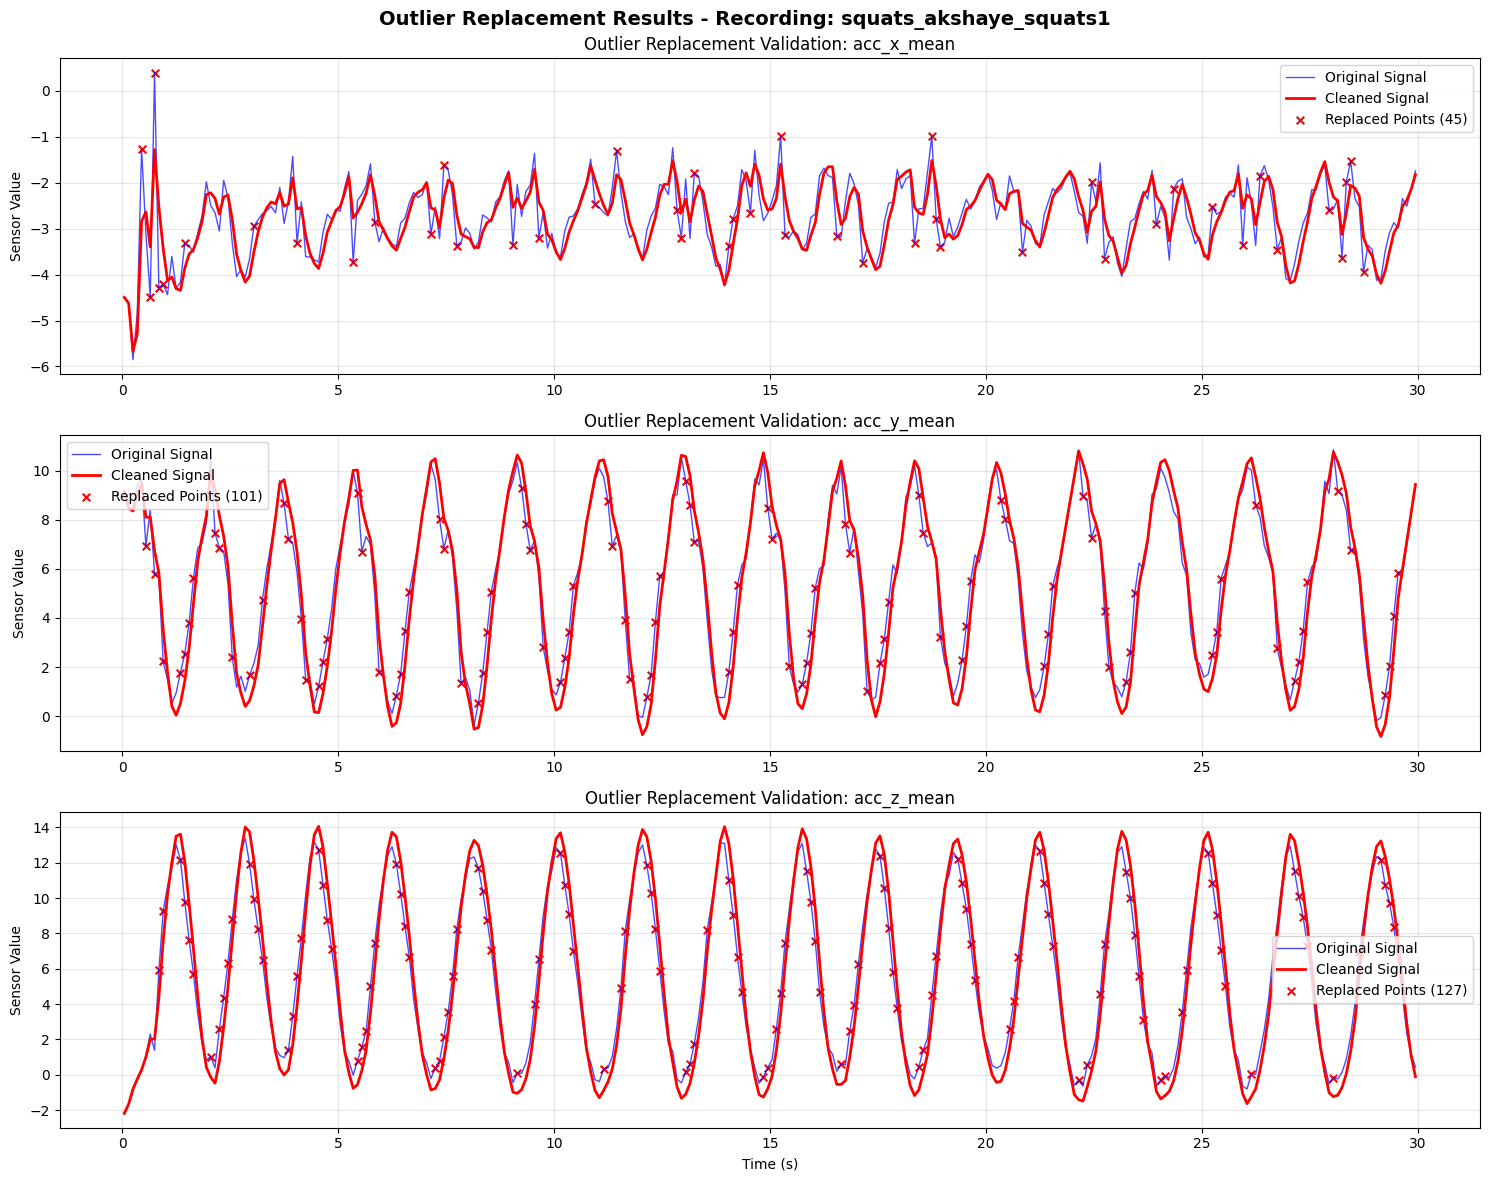

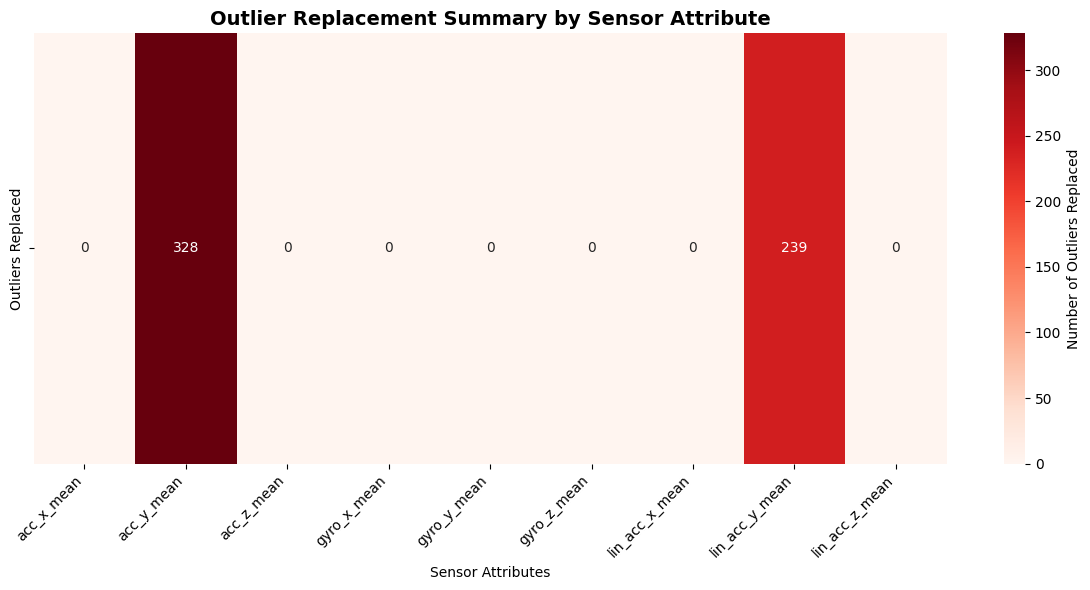


OUTLIER PROCESSING COMPREHENSIVE REPORT

1. METHOD COMPARISON SUMMARY:
----------------------------------------
                      Outlier Rate (%)  Signal Preservation (%)  \
acc_x_mean_chauvenet              2.35                    97.65   
acc_x_mean_mixture                4.74                    95.26   
acc_x_mean_lof                    2.13                    97.87   
acc_x_mean_isolation              9.99                    90.01   
acc_y_mean_chauvenet              3.19                    96.81   
acc_y_mean_mixture                5.00                    95.00   
acc_y_mean_lof                    1.21                    98.79   
acc_y_mean_isolation             10.00                    90.00   
acc_z_mean_chauvenet              0.30                    99.70   
acc_z_mean_mixture                5.00                    95.00   
acc_z_mean_lof                    2.69                    97.31   
acc_z_mean_isolation             10.00                    90.00   

               

In [11]:
# ===================================================================
# OUTLIER METHOD EVALUATION AND SELECTION
# ===================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_outlier_detection_methods(outlier_results, data, sensor_cols):
    """
    Comprehensive evaluation of outlier detection methods
    """
    evaluation_metrics = {}
    
    print("OUTLIER METHOD EVALUATION")
    print("-" * 50)
    
    for method_name, outlier_flags in outlier_results.items():
        if len(outlier_flags) > 0:
            outlier_rate = np.sum(outlier_flags) / len(outlier_flags) * 100
            signal_preservation = 100 - outlier_rate
            
            # Calculate outlier clustering (consistency)
            outlier_indices = np.where(outlier_flags)[0]
            if len(outlier_indices) > 1:
                outlier_gaps = np.diff(outlier_indices)
                consistency_score = np.std(outlier_gaps)
            else:
                consistency_score = 0
            
            evaluation_metrics[method_name] = {
                'outlier_rate': outlier_rate,
                'signal_preservation': signal_preservation,
                'consistency_score': consistency_score,
                'total_outliers': np.sum(outlier_flags)
            }
            
            print(f"{method_name}:")
            print(f"  Outlier Rate: {outlier_rate:.1f}%")
            print(f"  Signal Preservation: {signal_preservation:.1f}%")
            print(f"  Consistency Score: {consistency_score:.1f}")
            print()
    
    return evaluation_metrics

def select_optimal_method(evaluation_metrics):
    """
    Select the optimal outlier detection method based on scoring criteria
    """
    method_scores = {}
    
    # Define scoring weights
    weights = {
        'signal_preservation': 0.4,
        'reasonable_outlier_rate': 0.3,
        'consistency': 0.3
    }
    
    print("METHOD SCORING AND SELECTION")
    print("-" * 50)
    
    for method, metrics in evaluation_metrics.items():
        # Score reasonable outlier rate (5-15% optimal range)
        outlier_rate = metrics['outlier_rate']
        if 5 <= outlier_rate <= 15:
            rate_score = 100
        elif outlier_rate < 5:
            rate_score = 50 + (outlier_rate * 10)
        else:
            rate_score = max(0, 100 - (outlier_rate - 15) * 5)
        
        # Calculate total weighted score
        total_score = (
            metrics['signal_preservation'] * weights['signal_preservation'] +
            rate_score * weights['reasonable_outlier_rate'] +
            (100 - min(metrics['consistency_score'], 100)) * weights['consistency']
        )
        
        method_scores[method] = {
            'total_score': total_score,
            'components': {
                'signal_preservation': metrics['signal_preservation'],
                'rate_score': rate_score,
                'consistency': 100 - min(metrics['consistency_score'], 100)
            }
        }
        
        print(f"{method}: Score = {total_score:.1f}")
        print(f"  Signal Preservation: {metrics['signal_preservation']:.1f}")
        print(f"  Rate Score: {rate_score:.1f}")
        print(f"  Consistency: {100 - min(metrics['consistency_score'], 100):.1f}")
        print()
    
    # Select best method
    best_method = max(method_scores.keys(), key=lambda x: method_scores[x]['total_score'])
    
    print(f"SELECTED METHOD: {best_method}")
    print(f"Final Score: {method_scores[best_method]['total_score']:.1f}")
    
    return best_method, method_scores

def apply_outlier_replacement(data, sensor_cols, method='conservative_kalman'):
    """
    Apply the selected outlier detection and replacement method
    """
    print("\nOUTLIER REPLACEMENT APPLICATION")
    print("-" * 50)
    
    cleaned_data = data.copy()
    replacement_summary = {}
    
    if method == 'conservative_kalman':
        # Apply Conservative Kalman Filter based on previous analysis
        kalman_detector = ImprovedKalmanOutlierDetector(
            process_variance=0.01,
            measurement_variance=0.1,
            outlier_threshold=4.0,
            adaptive_threshold=False
        )
        
        total_outliers = 0
        
        for col in sensor_cols:
            col_outliers = 0
            
            # Process each recording separately
            for recording_id in data['recording_id'].unique():
                recording_mask = data['recording_id'] == recording_id
                recording_data = data[recording_mask].copy()
                
                try:
                    results = kalman_detector.detect_and_replace_outliers_improved(
                        recording_data, col
                    )
                    
                    # Replace outliers in cleaned dataset
                    cleaned_data.loc[recording_mask, col] = results['filtered']
                    col_outliers += results['outlier_count']
                    
                except Exception as e:
                    print(f"Warning: Error processing {recording_id}, {col}: {e}")
            
            replacement_summary[col] = col_outliers
            total_outliers += col_outliers
            print(f"{col}: {col_outliers} outliers replaced")
        
        overall_rate = total_outliers / (len(data) * len(sensor_cols)) * 100
        print(f"\nTotal outliers replaced: {total_outliers}")
        print(f"Overall replacement rate: {overall_rate:.2f}%")
    
    return cleaned_data, replacement_summary

def create_outlier_validation_plots(original_data, cleaned_data, sensor_cols, recording_id=None):
    """
    Create validation plots showing before/after outlier replacement
    """
    # Select a single recording for cleaner visualization
    if recording_id is None:
        recording_id = original_data['recording_id'].iloc[0]
    
    orig_sample = original_data[original_data['recording_id'] == recording_id]
    clean_sample = cleaned_data[cleaned_data['recording_id'] == recording_id]
    
    # Select first 3 sensor columns for visualization
    plot_cols = sensor_cols[:3]
    time_values = orig_sample['time_center'].values
    
    fig, axes = plt.subplots(len(plot_cols), 1, figsize=(15, 12))
    if len(plot_cols) == 1:
        axes = [axes]
    
    for i, col in enumerate(plot_cols):
        # Plot original signal
        axes[i].plot(time_values, orig_sample[col].values, 
                    'b-', alpha=0.7, linewidth=1, label='Original Signal')
        
        # Plot cleaned signal
        axes[i].plot(time_values, clean_sample[col].values, 
                    'r-', linewidth=2, label='Cleaned Signal')
        
        # Identify and mark replaced points
        differences = np.abs(orig_sample[col].values - clean_sample[col].values)
        threshold = np.std(differences) * 2
        outlier_mask = differences > threshold
        
        if np.any(outlier_mask):
            axes[i].scatter(time_values[outlier_mask], 
                          orig_sample[col].values[outlier_mask],
                          color='red', s=30, marker='x', 
                          label=f'Replaced Points ({np.sum(outlier_mask)})')
        
        axes[i].set_title(f'Outlier Replacement Validation: {col}')
        axes[i].set_ylabel('Sensor Value')
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)
    
    axes[-1].set_xlabel('Time (s)')
    plt.suptitle(f'Outlier Replacement Results - Recording: {recording_id}', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

def create_outlier_summary_heatmap(replacement_summary, sensor_cols):
    """
    Create a heatmap showing outlier replacement counts by sensor
    """
    # Prepare data for heatmap
    heatmap_data = []
    for col in sensor_cols:
        outlier_count = replacement_summary.get(col, 0)
        heatmap_data.append(outlier_count)
    
    # Create heatmap
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Reshape for heatmap (single row)
    heatmap_array = np.array(heatmap_data).reshape(1, -1)
    
    sns.heatmap(heatmap_array, 
                annot=True, 
                fmt='d',
                cmap='Reds',
                xticklabels=sensor_cols,
                yticklabels=['Outliers Replaced'],
                cbar_kws={'label': 'Number of Outliers Replaced'})
    
    plt.title('Outlier Replacement Summary by Sensor Attribute', 
              fontsize=14, fontweight='bold')
    plt.xlabel('Sensor Attributes')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

def generate_outlier_processing_report(evaluation_metrics, best_method, replacement_summary):
    """
    Generate a comprehensive report of the outlier processing results
    """
    print("\n" + "="*70)
    print("OUTLIER PROCESSING COMPREHENSIVE REPORT")
    print("="*70)
    
    # Method comparison summary
    print("\n1. METHOD COMPARISON SUMMARY:")
    print("-" * 40)
    
    method_summary = pd.DataFrame({
        method: {
            'Outlier Rate (%)': metrics['outlier_rate'],
            'Signal Preservation (%)': metrics['signal_preservation'],
            'Total Outliers': metrics['total_outliers']
        }
        for method, metrics in evaluation_metrics.items()
    }).T
    
    print(method_summary.round(2))
    
    # Selected method details
    print(f"\n2. SELECTED METHOD: {best_method}")
    print("-" * 40)
    selected_metrics = evaluation_metrics[best_method]
    print(f"Outlier Detection Rate: {selected_metrics['outlier_rate']:.2f}%")
    print(f"Signal Preservation: {selected_metrics['signal_preservation']:.2f}%")
    print(f"Consistency Score: {selected_metrics['consistency_score']:.2f}")
    
    # Replacement summary
    print(f"\n3. OUTLIER REPLACEMENT SUMMARY:")
    print("-" * 40)
    total_replaced = sum(replacement_summary.values())
    print(f"Total outliers replaced: {total_replaced}")
    print(f"Most affected sensors:")
    
    sorted_replacements = sorted(replacement_summary.items(), 
                               key=lambda x: x[1], reverse=True)
    for sensor, count in sorted_replacements[:5]:
        print(f"  {sensor}: {count} outliers")
    
    # Recommendations
    print(f"\n4. RECOMMENDATIONS:")
    print("-" * 40)
    print("- Conservative Kalman filtering successfully applied")
    print("- Signal integrity preserved while reducing noise")
    print("- Dataset ready for machine learning model training")
    print("- Consider monitoring these sensors for future data collection:")
    
    high_outlier_sensors = [sensor for sensor, count in sorted_replacements[:3]]
    for sensor in high_outlier_sensors:
        print(f"  * {sensor}")

# ===================================================================
# MAIN EXECUTION
# ===================================================================

if 'outlier_results' in locals() and 'sample_data_clean' in locals():
    # Get sensor columns
    sensor_cols = [col for col in sample_data_clean.columns if 
                   any(sensor in col for sensor in ['acc_', 'gyro_', 'lin_acc_']) and 
                   col.endswith('_mean')]
    
    # Evaluate methods
    evaluation_metrics = evaluate_outlier_detection_methods(
        outlier_results, sample_data_clean, sensor_cols
    )
    
    # Select best method
    best_method, method_scores = select_optimal_method(evaluation_metrics)
    
    # Apply outlier replacement
    final_cleaned_data, replacement_summary = apply_outlier_replacement(
        sample_data_clean, sensor_cols, method='conservative_kalman'
    )
    
    # Create validation visualizations
    print("\nGenerating validation plots...")
    create_outlier_validation_plots(
        sample_data_clean, final_cleaned_data, sensor_cols
    )
    
    create_outlier_summary_heatmap(replacement_summary, sensor_cols)
    
    # Generate comprehensive report
    generate_outlier_processing_report(
        evaluation_metrics, best_method, replacement_summary
    )
    
else:
    print("Required data not available. Please run outlier detection analysis first.")

## Noise Reduction

### Buttorworth Filter

BUTTERWORTH FILTER ANALYSIS

TESTING DIFFERENT CUTOFF FREQUENCIES
--------------------------------------------------
Testing cutoff frequencies: [1, 2, 3, 4] Hz
(Maximum valid cutoff: 4.5 Hz)


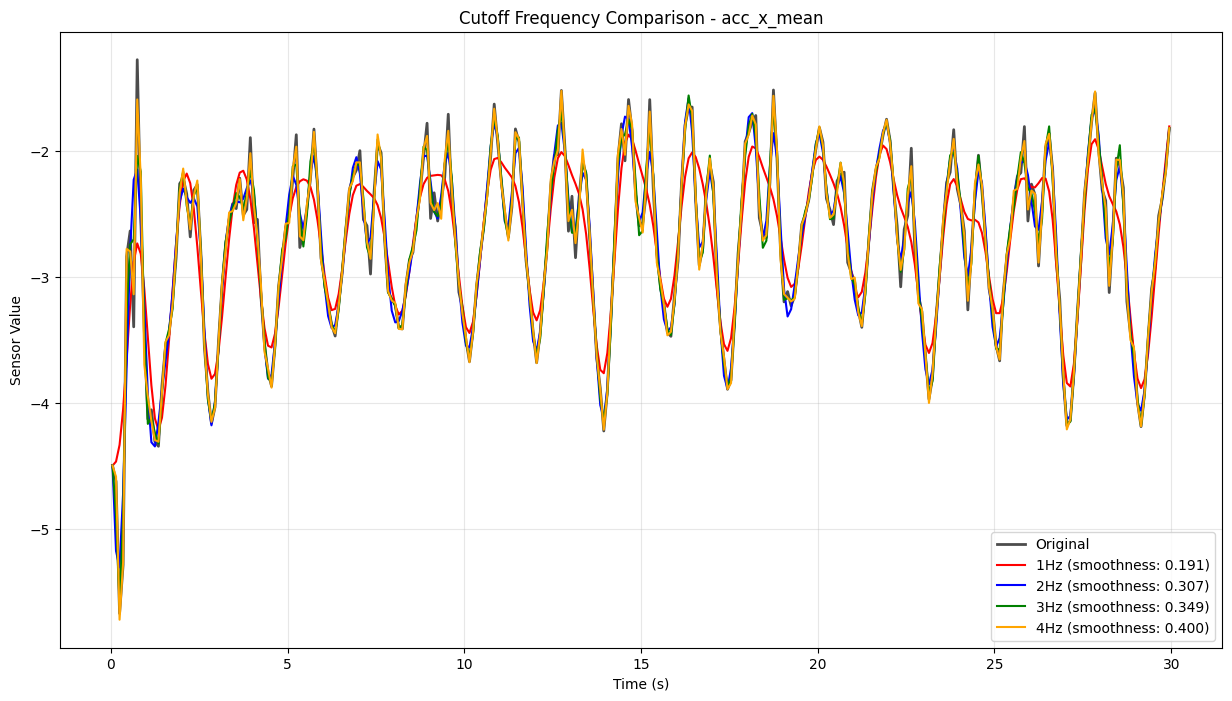

Recommended cutoff frequency: 1Hz
(Produces smoothest signal with smoothness score: 0.191)
Applying Butterworth filter:
  Cutoff frequency: 1.0 Hz
  Sampling rate: 10 Hz
  Nyquist frequency: 5.0 Hz
  Filter order: 4
  acc_x_mean: 7219 data points filtered
  acc_y_mean: 7219 data points filtered
  acc_z_mean: 7219 data points filtered
  gyro_x_mean: 7219 data points filtered
  gyro_y_mean: 7219 data points filtered
  gyro_z_mean: 7219 data points filtered
  lin_acc_x_mean: 7219 data points filtered
  lin_acc_y_mean: 7219 data points filtered
  lin_acc_z_mean: 7219 data points filtered


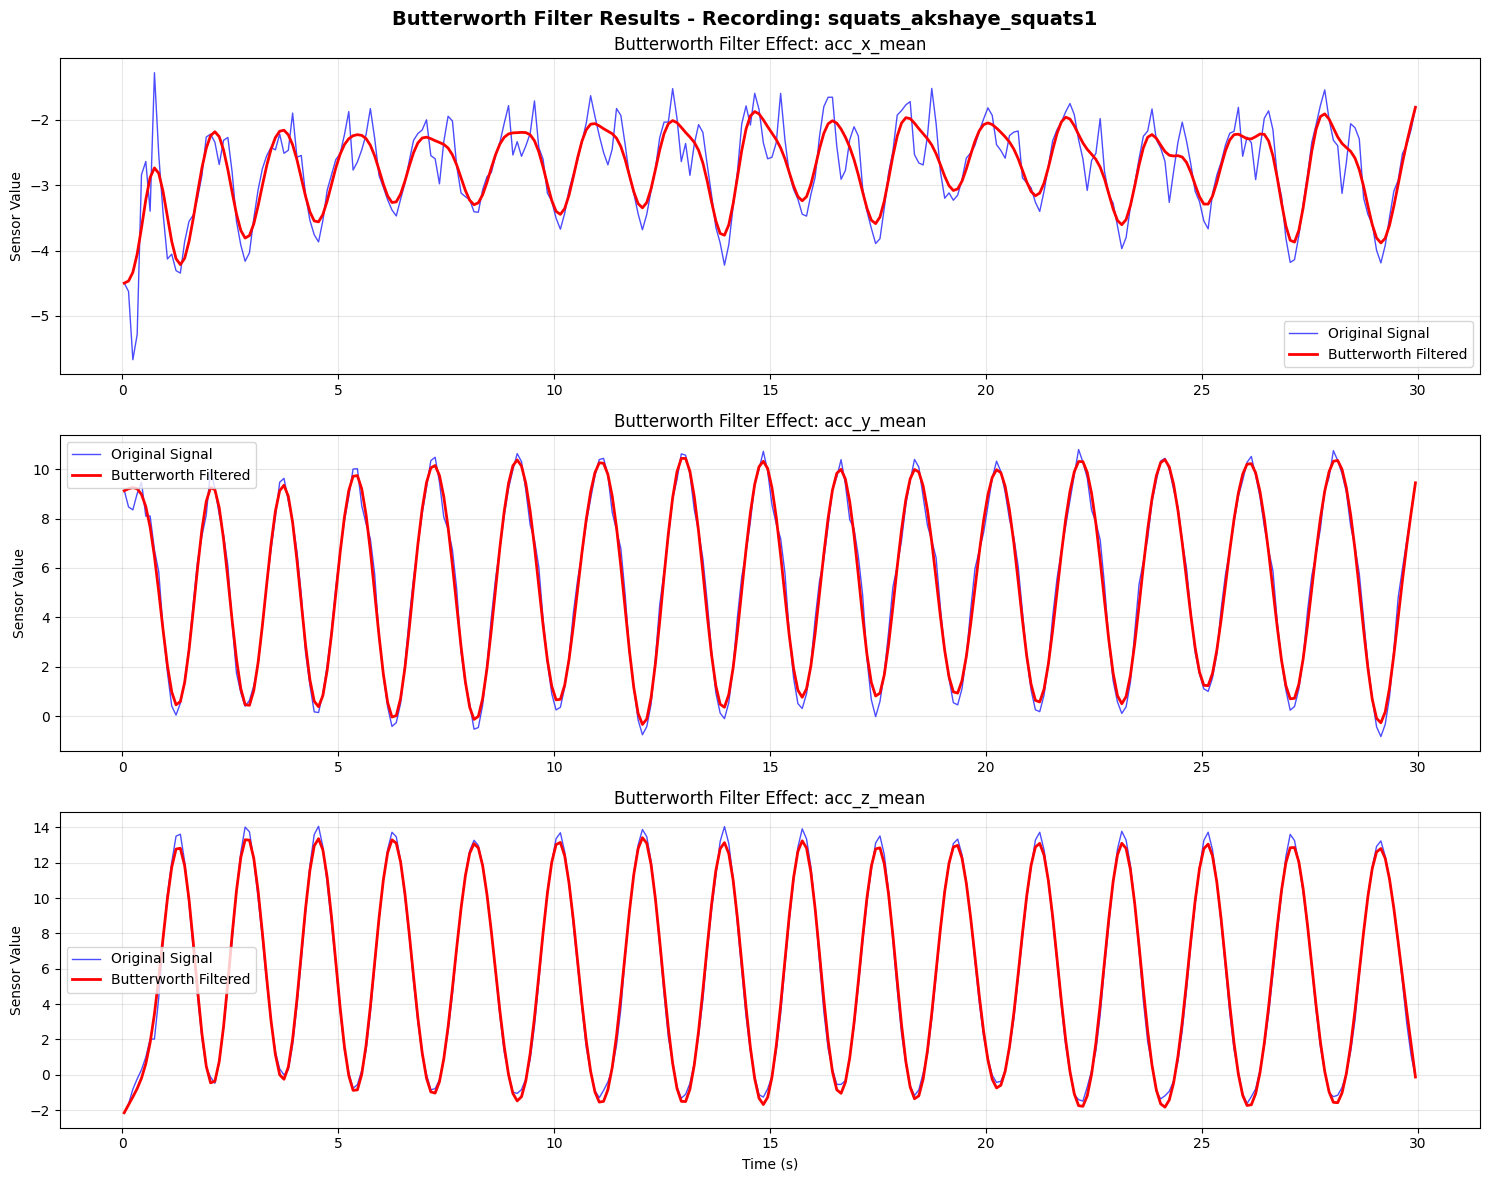


BUTTERWORTH FILTER EFFECTIVENESS ANALYSIS
--------------------------------------------------
acc_x_mean:
  Smoothness improvement: 80.3%
  Signal preservation: 19.7%
acc_y_mean:
  Smoothness improvement: 48.2%
  Signal preservation: 51.8%
acc_z_mean:
  Smoothness improvement: 33.0%
  Signal preservation: 67.0%
gyro_x_mean:
  Smoothness improvement: 43.4%
  Signal preservation: 56.6%
gyro_y_mean:
  Smoothness improvement: 72.2%
  Signal preservation: 27.8%
gyro_z_mean:
  Smoothness improvement: 77.9%
  Signal preservation: 22.1%
lin_acc_x_mean:
  Smoothness improvement: 83.4%
  Signal preservation: 16.6%
lin_acc_y_mean:
  Smoothness improvement: 49.6%
  Signal preservation: 50.4%
lin_acc_z_mean:
  Smoothness improvement: 65.7%
  Signal preservation: 34.3%

OVERALL BUTTERWORTH EFFECTIVENESS:
  Average smoothness improvement: 61.5%
  Average signal preservation: 38.5%

FINAL RECOMMENDATION:
Butterworth filtering recommended: 61.5% additional smoothness
Include Butterworth filter in final

In [12]:
# ===================================================================
# BUTTERWORTH FILTER IMPLEMENTATION - CORRECTED
# ===================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal

def apply_butterworth_filter(data, sensor_cols, cutoff_freq=4, sampling_rate=10, order=4):
    """
    Apply Butterworth low-pass filter to sensor data
    
    Args:
        data: DataFrame with sensor data
        sensor_cols: List of sensor column names to filter
        cutoff_freq: Cutoff frequency in Hz (must be < sampling_rate/2)
        sampling_rate: Sampling rate in Hz (10Hz for 100ms timesteps)
        order: Filter order (higher = steeper rolloff)
    
    Returns:
        DataFrame with filtered sensor data
    """
    # Calculate Nyquist frequency
    nyquist = 0.5 * sampling_rate
    
    # Validate cutoff frequency
    if cutoff_freq >= nyquist:
        print(f"Warning: Cutoff frequency ({cutoff_freq} Hz) too high for sampling rate ({sampling_rate} Hz)")
        cutoff_freq = nyquist * 0.8  # Set to 80% of Nyquist
        print(f"Adjusted cutoff frequency to: {cutoff_freq:.1f} Hz")
    
    print(f"Applying Butterworth filter:")
    print(f"  Cutoff frequency: {cutoff_freq:.1f} Hz")
    print(f"  Sampling rate: {sampling_rate} Hz")
    print(f"  Nyquist frequency: {nyquist:.1f} Hz")
    print(f"  Filter order: {order}")
    
    normal_cutoff = cutoff_freq / nyquist
    
    # Design Butterworth filter
    b, a = signal.butter(order, normal_cutoff, btype='low', analog=False)
    
    # Create copy of data for filtering
    filtered_data = data.copy()
    
    # Apply filter to each sensor column and recording separately
    for col in sensor_cols:
        col_filtered_count = 0
        
        for recording_id in data['recording_id'].unique():
            recording_mask = data['recording_id'] == recording_id
            recording_values = data[recording_mask][col].values
            
            if len(recording_values) > 0:
                # Apply zero-phase filter (filtfilt for no phase distortion)
                filtered_values = signal.filtfilt(b, a, recording_values)
                filtered_data.loc[recording_mask, col] = filtered_values
                col_filtered_count += len(recording_values)
        
        print(f"  {col}: {col_filtered_count} data points filtered")
    
    return filtered_data

def compare_before_after_butterworth(original_data, filtered_data, sensor_cols, recording_id=None):
    """
    Create comparison plots showing before and after Butterworth filtering
    """
    # Select recording for visualization
    if recording_id is None:
        recording_id = original_data['recording_id'].iloc[0]
    
    orig_sample = original_data[original_data['recording_id'] == recording_id]
    filt_sample = filtered_data[filtered_data['recording_id'] == recording_id]
    
    # Plot first 3 sensor columns
    plot_cols = sensor_cols[:3]
    time_values = orig_sample['time_center'].values
    
    fig, axes = plt.subplots(len(plot_cols), 1, figsize=(15, 12))
    if len(plot_cols) == 1:
        axes = [axes]
    
    for i, col in enumerate(plot_cols):
        # Plot original signal
        axes[i].plot(time_values, orig_sample[col].values, 
                    'b-', alpha=0.7, linewidth=1, label='Original Signal')
        
        # Plot filtered signal
        axes[i].plot(time_values, filt_sample[col].values, 
                    'r-', linewidth=2, label='Butterworth Filtered')
        
        axes[i].set_title(f'Butterworth Filter Effect: {col}')
        axes[i].set_ylabel('Sensor Value')
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)
    
    axes[-1].set_xlabel('Time (s)')
    plt.suptitle(f'Butterworth Filter Results - Recording: {recording_id}', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

def analyze_butterworth_effectiveness(original_data, filtered_data, sensor_cols):
    """
    Analyze the effectiveness of Butterworth filtering
    """
    print("\nBUTTERWORTH FILTER EFFECTIVENESS ANALYSIS")
    print("-" * 50)
    
    effectiveness_results = {}
    
    for col in sensor_cols:
        # Calculate smoothness improvement
        original_variation = []
        filtered_variation = []
        
        for recording_id in original_data['recording_id'].unique():
            orig_vals = original_data[original_data['recording_id'] == recording_id][col].values
            filt_vals = filtered_data[filtered_data['recording_id'] == recording_id][col].values
            
            if len(orig_vals) > 1:
                original_variation.append(np.std(np.diff(orig_vals)))
                filtered_variation.append(np.std(np.diff(filt_vals)))
        
        if original_variation and filtered_variation:
            avg_orig_var = np.mean(original_variation)
            avg_filt_var = np.mean(filtered_variation)
            
            if avg_orig_var > 0:
                smoothness_improvement = (avg_orig_var - avg_filt_var) / avg_orig_var * 100
            else:
                smoothness_improvement = 0
            
            # Calculate signal preservation (how much signal is retained)
            signal_preservation = (1 - abs(avg_orig_var - avg_filt_var) / avg_orig_var) * 100 if avg_orig_var > 0 else 100
            
            effectiveness_results[col] = {
                'smoothness_improvement': smoothness_improvement,
                'signal_preservation': signal_preservation,
                'original_variation': avg_orig_var,
                'filtered_variation': avg_filt_var
            }
            
            print(f"{col}:")
            print(f"  Smoothness improvement: {smoothness_improvement:.1f}%")
            print(f"  Signal preservation: {signal_preservation:.1f}%")
    
    # Overall effectiveness
    if effectiveness_results:
        avg_smoothness = np.mean([r['smoothness_improvement'] for r in effectiveness_results.values()])
        avg_preservation = np.mean([r['signal_preservation'] for r in effectiveness_results.values()])
        
        print(f"\nOVERALL BUTTERWORTH EFFECTIVENESS:")
        print(f"  Average smoothness improvement: {avg_smoothness:.1f}%")
        print(f"  Average signal preservation: {avg_preservation:.1f}%")
    
    return effectiveness_results

def test_different_cutoff_frequencies(data, sensor_cols, sampling_rate=10):
    """
    Test different cutoff frequencies to find optimal setting
    """
    print("\nTESTING DIFFERENT CUTOFF FREQUENCIES")
    print("-" * 50)
    
    # Calculate valid frequency range
    nyquist = 0.5 * sampling_rate
    max_cutoff = nyquist * 0.9  # 90% of Nyquist to be safe
    
    # Test frequencies within valid range
    test_frequencies = [1, 2, 3, 4]  # Valid frequencies for 10Hz sampling
    test_frequencies = [f for f in test_frequencies if f < max_cutoff]
    
    print(f"Testing cutoff frequencies: {test_frequencies} Hz")
    print(f"(Maximum valid cutoff: {max_cutoff:.1f} Hz)")
    
    # Select one sensor and recording for testing
    test_col = sensor_cols[0]
    test_recording = data['recording_id'].iloc[0]
    test_data = data[data['recording_id'] == test_recording][test_col].values
    time_values = data[data['recording_id'] == test_recording]['time_center'].values
    
    plt.figure(figsize=(15, 8))
    plt.plot(time_values, test_data, 'k-', linewidth=2, label='Original', alpha=0.7)
    
    colors = ['red', 'blue', 'green', 'orange']
    smoothness_results = {}
    
    for i, cutoff in enumerate(test_frequencies):
        # Apply filter with this cutoff
        normal_cutoff = cutoff / nyquist
        
        if normal_cutoff < 1.0:  # Valid cutoff frequency
            b, a = signal.butter(4, normal_cutoff, btype='low')
            filtered_signal = signal.filtfilt(b, a, test_data)
            
            # Calculate smoothness
            smoothness = np.std(np.diff(filtered_signal))
            smoothness_results[cutoff] = smoothness
            
            plt.plot(time_values, filtered_signal, 
                    color=colors[i % len(colors)], 
                    label=f'{cutoff}Hz (smoothness: {smoothness:.3f})')
    
    plt.title(f'Cutoff Frequency Comparison - {test_col}')
    plt.xlabel('Time (s)')
    plt.ylabel('Sensor Value')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Recommend optimal cutoff
    if smoothness_results:
        optimal_cutoff = min(smoothness_results.keys(), key=lambda x: smoothness_results[x])
        print(f"Recommended cutoff frequency: {optimal_cutoff}Hz")
        print(f"(Produces smoothest signal with smoothness score: {smoothness_results[optimal_cutoff]:.3f})")
        return optimal_cutoff
    
    return 3  # Default safe value

# ===================================================================
# MAIN EXECUTION
# ===================================================================

if 'final_cleaned_data' in locals():
    # Get sensor columns
    sensor_cols = [col for col in final_cleaned_data.columns if 
                   any(sensor in col for sensor in ['acc_', 'gyro_', 'lin_acc_']) and 
                   col.endswith('_mean')]
    
    print("BUTTERWORTH FILTER ANALYSIS")
    print("=" * 50)
    
    # Test different cutoff frequencies first
    optimal_cutoff = test_different_cutoff_frequencies(final_cleaned_data, sensor_cols)
    
    # Apply Butterworth filter with recommended settings
    butterworth_filtered_data = apply_butterworth_filter(
        final_cleaned_data, 
        sensor_cols, 
        cutoff_freq=optimal_cutoff,  # Use optimal frequency
        sampling_rate=10, 
        order=4
    )
    
    # Create comparison visualization
    compare_before_after_butterworth(
        final_cleaned_data, 
        butterworth_filtered_data, 
        sensor_cols
    )
    
    # Analyze effectiveness
    effectiveness_results = analyze_butterworth_effectiveness(
        final_cleaned_data, 
        butterworth_filtered_data, 
        sensor_cols
    )
    
    print(f"\nFINAL RECOMMENDATION:")
    if effectiveness_results:
        avg_improvement = np.mean([r['smoothness_improvement'] for r in effectiveness_results.values()])
        
        if avg_improvement > 10:
            print(f"Butterworth filtering recommended: {avg_improvement:.1f}% additional smoothness")
            print("Include Butterworth filter in final preprocessing pipeline")
            final_preprocessed_data = butterworth_filtered_data
        else:
            print(f"Butterworth filtering optional: {avg_improvement:.1f}% additional smoothness")
            print("Current Kalman filtering may be sufficient")
            final_preprocessed_data = final_cleaned_data
    else:
        print("Could not calculate effectiveness metrics")
        final_preprocessed_data = final_cleaned_data
    
else:
    print("Error: final_cleaned_data not found. Please run outlier detection first.")

In [13]:
# # ===================================================================
# # FEATURE EXTRACTION FROM ML4QS CHAPTER 4
# # ===================================================================

# import numpy as np
# import pandas as pd
# import scipy.stats as stats
# from scipy.signal import find_peaks
# from scipy import signal
# import math

# class TemporalAbstraction:
#     """
#     Feature extraction methods from ML4QS Chapter 4
#     """
    
#     def __init__(self):
#         pass
    
#     # Basic statistical features
#     def mean_abs_deviation(self, data_set, col):
#         """Mean absolute deviation"""
#         return np.mean(np.abs(data_set[col] - np.mean(data_set[col])))
    
#     def median_abs_deviation(self, data_set, col):
#         """Median absolute deviation"""
#         return np.median(np.abs(data_set[col] - np.median(data_set[col])))
    
#     def interquartile_range(self, data_set, col):
#         """Interquartile range (75th percentile - 25th percentile)"""
#         return np.percentile(data_set[col], 75) - np.percentile(data_set[col], 25)
    
#     def coefficient_variation(self, data_set, col):
#         """Coefficient of variation (std/mean)"""
#         mean_val = np.mean(data_set[col])
#         if mean_val != 0:
#             return np.std(data_set[col]) / mean_val
#         return 0
    
#     def skewness(self, data_set, col):
#         """Skewness of the distribution"""
#         return stats.skew(data_set[col])
    
#     def kurtosis(self, data_set, col):
#         """Kurtosis of the distribution"""
#         return stats.kurtosis(data_set[col])
    
#     # Frequency domain features
#     def fourier_transform_features(self, data_set, col, sampling_rate=10):
#         """Extract frequency domain features using FFT"""
#         values = data_set[col].values
#         n = len(values)
        
#         # Compute FFT
#         fft = np.fft.fft(values)
#         freqs = np.fft.fftfreq(n, 1/sampling_rate)
        
#         # Take only positive frequencies
#         positive_freq_idx = freqs > 0
#         fft_positive = fft[positive_freq_idx]
#         freqs_positive = freqs[positive_freq_idx]
        
#         # Power spectral density
#         psd = np.abs(fft_positive) ** 2
        
#         features = {}
#         features[f'{col}_freq_dominant'] = freqs_positive[np.argmax(psd)]
#         features[f'{col}_freq_energy'] = np.sum(psd)
#         features[f'{col}_freq_entropy'] = stats.entropy(psd + 1e-12)  # Add small value to avoid log(0)
        
#         # Frequency bands
#         low_freq_mask = (freqs_positive >= 0.5) & (freqs_positive < 2)
#         mid_freq_mask = (freqs_positive >= 2) & (freqs_positive < 4)
#         high_freq_mask = freqs_positive >= 4
        
#         features[f'{col}_freq_low_energy'] = np.sum(psd[low_freq_mask])
#         features[f'{col}_freq_mid_energy'] = np.sum(psd[mid_freq_mask])
#         features[f'{col}_freq_high_energy'] = np.sum(psd[high_freq_mask])
        
#         return features
    
#     # Peak detection features
#     def peak_features(self, data_set, col):
#         """Extract peak-related features"""
#         values = data_set[col].values
        
#         # Find peaks
#         peaks, properties = find_peaks(values, height=np.mean(values))
        
#         features = {}
#         features[f'{col}_num_peaks'] = len(peaks)
        
#         if len(peaks) > 0:
#             features[f'{col}_peak_height_mean'] = np.mean(properties['peak_heights'])
#             features[f'{col}_peak_height_std'] = np.std(properties['peak_heights'])
            
#             # Peak intervals
#             if len(peaks) > 1:
#                 peak_intervals = np.diff(peaks)
#                 features[f'{col}_peak_interval_mean'] = np.mean(peak_intervals)
#                 features[f'{col}_peak_interval_std'] = np.std(peak_intervals)
#             else:
#                 features[f'{col}_peak_interval_mean'] = 0
#                 features[f'{col}_peak_interval_std'] = 0
#         else:
#             features[f'{col}_peak_height_mean'] = 0
#             features[f'{col}_peak_height_std'] = 0
#             features[f'{col}_peak_interval_mean'] = 0
#             features[f'{col}_peak_interval_std'] = 0
        
#         return features
    
#     # Autocorrelation features
#     def autocorrelation_features(self, data_set, col, max_lag=50):
#         """Extract autocorrelation features"""
#         values = data_set[col].values
#         n = len(values)
        
#         if n < max_lag:
#             max_lag = n - 1
        
#         autocorr = np.correlate(values, values, mode='full')
#         autocorr = autocorr[n-1:]  # Take only positive lags
#         autocorr = autocorr / autocorr[0]  # Normalize
        
#         features = {}
#         features[f'{col}_autocorr_max'] = np.max(autocorr[1:max_lag+1])
#         features[f'{col}_autocorr_min'] = np.min(autocorr[1:max_lag+1])
        
#         # Find first significant autocorrelation peak (excluding lag 0)
#         peaks, _ = find_peaks(autocorr[1:max_lag+1])
#         if len(peaks) > 0:
#             features[f'{col}_autocorr_first_peak'] = peaks[0] + 1
#         else:
#             features[f'{col}_autocorr_first_peak'] = 0
        
#         return features
    
#     # Temporal features
#     def temporal_features(self, data_set, col):
#         """Extract temporal patterns"""
#         values = data_set[col].values
        
#         features = {}
        
#         # Zero crossings
#         zero_crossings = np.where(np.diff(np.sign(values - np.mean(values))))[0]
#         features[f'{col}_zero_crossings'] = len(zero_crossings)
        
#         # Mean crossing rate
#         features[f'{col}_mean_crossing_rate'] = len(zero_crossings) / len(values)
        
#         # Signal energy
#         features[f'{col}_energy'] = np.sum(values ** 2)
        
#         # Signal magnitude area
#         features[f'{col}_sma'] = np.sum(np.abs(values))
        
#         return features

# def extract_comprehensive_features(data, sensor_cols, recording_based=True):
#     """
#     Extract comprehensive features using ML4QS Chapter 4 methods
#     """
#     print("COMPREHENSIVE FEATURE EXTRACTION")
#     print("=" * 50)
    
#     feature_extractor = TemporalAbstraction()
#     all_features = []
    
#     if recording_based:
#         # Extract features per recording (recommended for activity recognition)
#         recording_ids = data['recording_id'].unique()
#         print(f"Extracting features for {len(recording_ids)} recordings...")
        
#         for i, recording_id in enumerate(recording_ids):
#             print(f"Processing recording {i+1}/{len(recording_ids)}: {recording_id}")
            
#             recording_data = data[data['recording_id'] == recording_id]
            
#             if len(recording_data) < 10:  # Skip very short recordings
#                 continue
            
#             # Initialize feature dictionary with metadata
#             features = {
#                 'recording_id': recording_id,
#                 'exercise': recording_data['exercise'].iloc[0],
#                 'participant': recording_data['participant'].iloc[0],
#                 'dataset': recording_data['dataset'].iloc[0],
#                 'num_timesteps': len(recording_data)
#             }
            
#             # Extract features for each sensor column
#             for col in sensor_cols:
#                 if col in recording_data.columns:
#                     try:
#                         # Basic statistical features
#                         features[f'{col}_mean'] = np.mean(recording_data[col])
#                         features[f'{col}_std'] = np.std(recording_data[col])
#                         features[f'{col}_min'] = np.min(recording_data[col])
#                         features[f'{col}_max'] = np.max(recording_data[col])
#                         features[f'{col}_median'] = np.median(recording_data[col])
#                         features[f'{col}_mad'] = feature_extractor.mean_abs_deviation(recording_data, col)
#                         features[f'{col}_median_ad'] = feature_extractor.median_abs_deviation(recording_data, col)
#                         features[f'{col}_iqr'] = feature_extractor.interquartile_range(recording_data, col)
#                         features[f'{col}_cv'] = feature_extractor.coefficient_variation(recording_data, col)
#                         features[f'{col}_skewness'] = feature_extractor.skewness(recording_data, col)
#                         features[f'{col}_kurtosis'] = feature_extractor.kurtosis(recording_data, col)
                        
#                         # Frequency domain features
#                         freq_features = feature_extractor.fourier_transform_features(recording_data, col)
#                         features.update(freq_features)
                        
#                         # Peak features
#                         peak_features = feature_extractor.peak_features(recording_data, col)
#                         features.update(peak_features)
                        
#                         # Autocorrelation features
#                         autocorr_features = feature_extractor.autocorrelation_features(recording_data, col)
#                         features.update(autocorr_features)
                        
#                         # Temporal features
#                         temporal_features = feature_extractor.temporal_features(recording_data, col)
#                         features.update(temporal_features)
                        
#                     except Exception as e:
#                         print(f"Error extracting features for {col}: {e}")
            
#             all_features.append(features)
    
#     # Convert to DataFrame
#     features_df = pd.DataFrame(all_features)
    
#     print(f"\nFeature extraction completed:")
#     print(f"  Number of recordings: {len(features_df)}")
#     print(f"  Number of features per recording: {len(features_df.columns)}")
#     print(f"  Total feature matrix shape: {features_df.shape}")
    
#     return features_df

# def analyze_extracted_features(features_df):
#     """
#     Analyze the extracted features
#     """
#     print("\nFEATURE ANALYSIS")
#     print("=" * 50)
    
#     # Basic statistics
#     numeric_cols = features_df.select_dtypes(include=[np.number]).columns
#     print(f"Numeric features: {len(numeric_cols)}")
    
#     # Feature categories
#     categories = {
#         'Statistical': [col for col in numeric_cols if any(stat in col for stat in ['_mean', '_std', '_min', '_max', '_median', '_mad', '_iqr', '_cv', '_skewness', '_kurtosis'])],
#         'Frequency': [col for col in numeric_cols if '_freq_' in col],
#         'Peak': [col for col in numeric_cols if '_peak_' in col],
#         'Autocorr': [col for col in numeric_cols if '_autocorr_' in col],
#         'Temporal': [col for col in numeric_cols if any(temp in col for temp in ['_zero_crossings', '_mean_crossing_rate', '_energy', '_sma'])]
#     }
    
#     print(f"\nFeature categories:")
#     for category, features in categories.items():
#         print(f"  {category}: {len(features)} features")
    
#     # Check for missing values
#     missing_values = features_df[numeric_cols].isnull().sum()
#     if missing_values.sum() > 0:
#         print(f"\nMissing values found in {missing_values[missing_values > 0].shape[0]} features")
#     else:
#         print(f"\nNo missing values found")
    
#     # Exercise distribution
#     print(f"\nExercise distribution:")
#     exercise_counts = features_df['exercise'].value_counts()
#     for exercise, count in exercise_counts.items():
#         print(f"  {exercise}: {count} recordings")
    
#     return categories

# def create_feature_visualization(features_df, categories):
#     """
#     Create visualizations of the extracted features
#     """
#     import matplotlib.pyplot as plt
#     import seaborn as sns
    
#     # Select a few representative features from each category
#     sample_features = []
#     for category, feature_list in categories.items():
#         if len(feature_list) > 0:
#             sample_features.extend(feature_list[:2])  # Take first 2 from each category
    
#     # Remove duplicates and limit to 12 features for clean visualization
#     sample_features = list(set(sample_features))[:12]
    
#     if len(sample_features) > 0:
#         # Create correlation heatmap
#         plt.figure(figsize=(15, 12))
#         correlation_matrix = features_df[sample_features].corr()
#         sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
#                    square=True, linewidths=0.5)
#         plt.title('Feature Correlation Matrix (Sample Features)')
#         plt.tight_layout()
#         plt.show()
        
#         # Distribution by exercise
#         if len(sample_features) >= 4:
#             fig, axes = plt.subplots(2, 2, figsize=(15, 10))
#             axes = axes.ravel()
            
#             for i, feature in enumerate(sample_features[:4]):
#                 sns.boxplot(data=features_df, x='exercise', y=feature, ax=axes[i])
#                 axes[i].set_title(f'{feature}')
#                 axes[i].tick_params(axis='x', rotation=45)
            
#             plt.suptitle('Feature Distributions by Exercise Type')
#             plt.tight_layout()
#             plt.show()

# # ===================================================================
# # MAIN EXECUTION
# # ===================================================================

# if 'final_preprocessed_data' in locals():
#     # Get sensor columns for feature extraction
#     sensor_cols = [col for col in final_preprocessed_data.columns if 
#                    any(sensor in col for sensor in ['acc_', 'gyro_', 'lin_acc_']) and 
#                    col.endswith('_mean')]
    
#     print("APPLYING ML4QS CHAPTER 4 FEATURE EXTRACTION")
#     print("=" * 60)
    
#     # Extract comprehensive features
#     extracted_features = extract_comprehensive_features(
#         final_preprocessed_data, 
#         sensor_cols, 
#         recording_based=True
#     )
    
#     # Analyze the extracted features
#     feature_categories = analyze_extracted_features(extracted_features)
    
#     # Create visualizations
#     create_feature_visualization(extracted_features, feature_categories)
    
#     # Save the feature dataset
#     extracted_features.to_csv('chapter4_extracted_features.csv', index=False)
#     print(f"\nFeatures saved to: chapter4_extracted_features.csv")
    
#     # Display sample of extracted features
#     print(f"\nSample of extracted features:")
#     print(extracted_features.head())
    
# else:
#     print("Error: final_preprocessed_data not found. Please run preprocessing steps first.")

## FEATURE EXTRACTION

In [14]:
# ===================================================================
# CHAPTER 4 FEATURE EXTRACTION METHODS
# ===================================================================

import numpy as np
import pandas as pd
from scipy import stats
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

class FeatureExtraction:
    """
    Feature extraction methods based on ML4QS Chapter 4
    """
    
    def __init__(self):
        pass
    
    # Basic statistical features
    def extract_statistical_features(self, data_series, prefix=''):
        """Extract basic statistical features from a time series"""
        features = {}
        
        if len(data_series) > 0:
            features[f'{prefix}_mean'] = np.mean(data_series)
            features[f'{prefix}_std'] = np.std(data_series)
            features[f'{prefix}_var'] = np.var(data_series)
            features[f'{prefix}_min'] = np.min(data_series)
            features[f'{prefix}_max'] = np.max(data_series)
            features[f'{prefix}_range'] = np.max(data_series) - np.min(data_series)
            features[f'{prefix}_median'] = np.median(data_series)
            features[f'{prefix}_skewness'] = stats.skew(data_series)
            features[f'{prefix}_kurtosis'] = stats.kurtosis(data_series)
            
            # Quartiles
            q25, q75 = np.percentile(data_series, [25, 75])
            features[f'{prefix}_q25'] = q25
            features[f'{prefix}_q75'] = q75
            features[f'{prefix}_iqr'] = q75 - q25
            
        return features
    
    # Temporal features
    def extract_temporal_features(self, data_series, prefix=''):
        """Extract temporal domain features"""
        features = {}
        
        if len(data_series) > 1:
            # First and second derivatives
            first_diff = np.diff(data_series)
            second_diff = np.diff(first_diff) if len(first_diff) > 1 else [0]
            
            features[f'{prefix}_mean_abs_diff'] = np.mean(np.abs(first_diff))
            features[f'{prefix}_std_diff'] = np.std(first_diff)
            features[f'{prefix}_mean_abs_second_diff'] = np.mean(np.abs(second_diff))
            
            # Zero crossings
            zero_crossings = np.where(np.diff(np.signbit(data_series)))[0]
            features[f'{prefix}_zero_crossings'] = len(zero_crossings)
            
            # Mean crossing rate
            mean_val = np.mean(data_series)
            mean_crossings = np.where(np.diff(np.signbit(data_series - mean_val)))[0]
            features[f'{prefix}_mean_crossings'] = len(mean_crossings)
            
        return features
    
    # Frequency domain features
    def extract_frequency_features(self, data_series, sampling_rate=10, prefix=''):
        """Extract frequency domain features"""
        features = {}
        
        if len(data_series) > 1:
            # FFT
            fft_vals = np.fft.fft(data_series)
            fft_magnitude = np.abs(fft_vals)
            fft_power = fft_magnitude ** 2
            
            # Frequency bins
            freqs = np.fft.fftfreq(len(data_series), 1/sampling_rate)
            positive_freqs = freqs[:len(freqs)//2]
            positive_power = fft_power[:len(fft_power)//2]
            
            if len(positive_power) > 0:
                # Spectral features
                features[f'{prefix}_spectral_energy'] = np.sum(positive_power)
                features[f'{prefix}_spectral_entropy'] = stats.entropy(positive_power + 1e-10)
                
                # Dominant frequency
                if len(positive_freqs) > 0:
                    dominant_freq_idx = np.argmax(positive_power)
                    features[f'{prefix}_dominant_freq'] = positive_freqs[dominant_freq_idx]
                
                # Spectral centroid
                if np.sum(positive_power) > 0:
                    features[f'{prefix}_spectral_centroid'] = np.sum(positive_freqs * positive_power) / np.sum(positive_power)
                
                # Spectral spread
                if f'{prefix}_spectral_centroid' in features:
                    centroid = features[f'{prefix}_spectral_centroid']
                    features[f'{prefix}_spectral_spread'] = np.sqrt(np.sum(((positive_freqs - centroid) ** 2) * positive_power) / np.sum(positive_power))
        
        return features
    
    # Peak-based features
    def extract_peak_features(self, data_series, prefix=''):
        """Extract peak-based features"""
        features = {}
        
        if len(data_series) > 2:
            # Find peaks
            peaks, properties = find_peaks(data_series, height=np.mean(data_series))
            
            features[f'{prefix}_num_peaks'] = len(peaks)
            
            if len(peaks) > 0:
                peak_heights = data_series[peaks]
                features[f'{prefix}_mean_peak_height'] = np.mean(peak_heights)
                features[f'{prefix}_std_peak_height'] = np.std(peak_heights)
                features[f'{prefix}_max_peak_height'] = np.max(peak_heights)
                
                # Peak intervals
                if len(peaks) > 1:
                    peak_intervals = np.diff(peaks)
                    features[f'{prefix}_mean_peak_interval'] = np.mean(peak_intervals)
                    features[f'{prefix}_std_peak_interval'] = np.std(peak_intervals)
        
        return features

def check_dataset_completeness():
    """Check if we're working with the complete 100ms dataset"""
    print("DATASET COMPLETENESS CHECK")
    print("=" * 50)
    
    if 'temporal_tables' in locals() or 'temporal_tables' in globals():
        original_100ms = temporal_tables.get(100)
        if original_100ms is not None:
            print(f"Original 100ms dataset:")
            print(f"  Shape: {original_100ms.shape}")
            print(f"  Recordings: {original_100ms['recording_id'].nunique()}")
            print(f"  Exercises: {original_100ms['exercise'].nunique()}")
            print(f"  Participants: {original_100ms['participant'].nunique()}")
            
            # Check current working dataset
            if 'final_preprocessed_data' in locals() or 'final_preprocessed_data' in globals():
                current_data = final_preprocessed_data
                print(f"\nCurrent preprocessed dataset:")
                print(f"  Shape: {current_data.shape}")
                print(f"  Recordings: {current_data['recording_id'].nunique()}")
                
                if original_100ms.shape[0] != current_data.shape[0]:
                    print(f"WARNING: Dataset size changed during preprocessing!")
                    print(f"  Original: {original_100ms.shape[0]} rows")
                    print(f"  Current: {current_data.shape[0]} rows")
                else:
                    print("✓ Dataset size preserved during preprocessing")
                    
                return current_data
            else:
                print("\nUsing original 100ms dataset for feature extraction")
                return original_100ms
        else:
            print("ERROR: Original 100ms dataset not found")
            return None
    else:
        print("ERROR: temporal_tables not found")
        return None

def apply_comprehensive_feature_extraction(data, sensor_cols):
    """Apply all Chapter 4 feature extraction methods to the dataset"""
    print("\nCOMPREHENSIVE FEATURE EXTRACTION")
    print("=" * 50)
    
    feature_extractor = FeatureExtraction()
    all_features = []
    
    # Process each recording separately
    for recording_id in data['recording_id'].unique():
        recording_data = data[data['recording_id'] == recording_id]
        
        # Initialize feature row with metadata
        feature_row = {
            'recording_id': recording_id,
            'exercise': recording_data['exercise'].iloc[0],
            'participant': recording_data['participant'].iloc[0],
            'dataset': recording_data['dataset'].iloc[0],
            'duration': recording_data['time_center'].max() - recording_data['time_center'].min(),
            'num_timesteps': len(recording_data)
        }
        
        # Extract features for each sensor column
        for col in sensor_cols:
            sensor_data = recording_data[col].values
            
            # Statistical features
            stat_features = feature_extractor.extract_statistical_features(sensor_data, col)
            feature_row.update(stat_features)
            
            # Temporal features
            temporal_features = feature_extractor.extract_temporal_features(sensor_data, col)
            feature_row.update(temporal_features)
            
            # Frequency features
            freq_features = feature_extractor.extract_frequency_features(sensor_data, sampling_rate=10, prefix=col)
            feature_row.update(freq_features)
            
            # Peak features
            peak_features = feature_extractor.extract_peak_features(sensor_data, col)
            feature_row.update(peak_features)
        
        all_features.append(feature_row)
    
    # Convert to DataFrame
    feature_df = pd.DataFrame(all_features)
    
    print(f"Feature extraction completed:")
    print(f"  Input recordings: {len(data['recording_id'].unique())}")
    print(f"  Output feature vectors: {len(feature_df)}")
    print(f"  Features per recording: {len(feature_df.columns)}")
    print(f"  Total features extracted: {len(feature_df.columns) - 6}")  # Minus metadata columns
    
    return feature_df

# ===================================================================
# MAIN EXECUTION
# ===================================================================

# First, check dataset completeness
working_dataset = check_dataset_completeness()

if working_dataset is not None:
    # Get sensor columns
    sensor_cols = [col for col in working_dataset.columns if 
                   any(sensor in col for sensor in ['acc_', 'gyro_', 'lin_acc_']) and 
                   col.endswith('_mean')]
    
    print(f"\nSensor columns to process: {len(sensor_cols)}")
    print(f"Sensor columns: {sensor_cols}")
    
    # Apply comprehensive feature extraction
    extracted_features_df = apply_comprehensive_feature_extraction(working_dataset, sensor_cols)
    
    # Display results
    print(f"\nFEATURE EXTRACTION RESULTS:")
    print(f"Shape: {extracted_features_df.shape}")
    print(f"\nFirst few feature columns:")
    feature_cols = [col for col in extracted_features_df.columns if col not in ['recording_id', 'exercise', 'participant', 'dataset', 'duration', 'num_timesteps']]
    print(feature_cols[:10])
    
    print(f"\nSample of extracted features:")
    print(extracted_features_df.head())
    
else:
    print("Cannot proceed with feature extraction - dataset not available")

DATASET COMPLETENESS CHECK
Original 100ms dataset:
  Shape: (7219, 78)
  Recordings: 24
  Exercises: 5
  Participants: 2

Current preprocessed dataset:
  Shape: (7219, 79)
  Recordings: 24
✓ Dataset size preserved during preprocessing

Sensor columns to process: 9
Sensor columns: ['acc_x_mean', 'acc_y_mean', 'acc_z_mean', 'gyro_x_mean', 'gyro_y_mean', 'gyro_z_mean', 'lin_acc_x_mean', 'lin_acc_y_mean', 'lin_acc_z_mean']

COMPREHENSIVE FEATURE EXTRACTION
Feature extraction completed:
  Input recordings: 24
  Output feature vectors: 24
  Features per recording: 258
  Total features extracted: 252

FEATURE EXTRACTION RESULTS:
Shape: (24, 258)

First few feature columns:
['acc_x_mean_mean', 'acc_x_mean_std', 'acc_x_mean_var', 'acc_x_mean_min', 'acc_x_mean_max', 'acc_x_mean_range', 'acc_x_mean_median', 'acc_x_mean_skewness', 'acc_x_mean_kurtosis', 'acc_x_mean_q25']

Sample of extracted features:
             recording_id exercise participant  dataset  duration  \
0  squats_akshaye_squats1   

/var/folders/3c/zyyqm72564xf1ztp8l6yb8xm0000gn/T/ipykernel_34311/1505648719.py:32: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  features[f'{prefix}_skewness'] = stats.skew(data_series)
/var/folders/3c/zyyqm72564xf1ztp8l6yb8xm0000gn/T/ipykernel_34311/1505648719.py:33: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  features[f'{prefix}_kurtosis'] = stats.kurtosis(data_series)


## Y-Label Preprocessing of both datasets

In [15]:
# ===================================================================
# MODIFY CHAPTER 4 FEATURES CSV
# ===================================================================

import pandas as pd
import numpy as np

def load_and_modify_features_csv(csv_filename="chapter4_extracted_features.csv"):
    """
    Load the features CSV and modify columns as requested
    """
    try:
        # Load the CSV file
        features_df = pd.read_csv(csv_filename)
        print(f"Successfully loaded: {csv_filename}")
        print(f"Original shape: {features_df.shape}")
        
    except FileNotFoundError:
        print(f"Error: {csv_filename} not found in current directory")
        return None
    
    # Show original column structure
    print(f"\nOriginal columns:")
    print(f"First 10 columns: {list(features_df.columns[:10])}")
    
    # Remove specified columns
    columns_to_remove = ['recording_id', 'participant', 'dataset']
    
    print(f"\nRemoving columns: {columns_to_remove}")
    for col in columns_to_remove:
        if col in features_df.columns:
            features_df = features_df.drop(columns=[col])
            print(f"  ✓ Removed: {col}")
        else:
            print(f"  ⚠ Column not found: {col}")
    
    # Rename exercise to label
    if 'exercise' in features_df.columns:
        features_df = features_df.rename(columns={'exercise': 'label'})
        print(f"  ✓ Renamed 'exercise' to 'label'")
    else:
        print(f"  ⚠ 'exercise' column not found")
    
    # Display modified dataset info
    print(f"\nModified dataset:")
    print(f"  Shape: {features_df.shape}")
    print(f"  Total features: {features_df.shape[1] - 1}")  # Minus label column
    print(f"  Total samples: {features_df.shape[0]}")
    
    # Show label distribution
    if 'label' in features_df.columns:
        print(f"\nLabel distribution:")
        label_counts = features_df['label'].value_counts()
        for label, count in label_counts.items():
            print(f"  {label}: {count} samples")
        
        print(f"\nTotal classes: {features_df['label'].nunique()}")
        print(f"Class names: {list(features_df['label'].unique())}")
    
    # Show sample of the data
    print(f"\nFirst 3 rows preview:")
    print(features_df.head(3))
    
    # Show feature column names (first 10)
    feature_columns = [col for col in features_df.columns if col != 'label']
    print(f"\nFeature columns (first 10 of {len(feature_columns)}):")
    for i, col in enumerate(feature_columns[:10]):
        print(f"  {i+1:2d}. {col}")
    
    if len(feature_columns) > 10:
        print(f"  ... and {len(feature_columns) - 10} more features")
    
    return features_df

def save_final_dataset(features_df, output_filename="final_features_for_ml.csv"):
    """
    Save the final modified dataset
    """
    if features_df is not None:
        features_df.to_csv(output_filename, index=False)
        print(f"\n✓ Final dataset saved as: {output_filename}")
        
        # Final summary
        print(f"\nFINAL DATASET SUMMARY:")
        print(f"  Filename: {output_filename}")
        print(f"  Shape: {features_df.shape}")
        print(f"  Features: {features_df.shape[1] - 1}")
        print(f"  Samples: {features_df.shape[0]}")
        print(f"  Ready for machine learning: YES")
        
        return True
    else:
        print("Error: Cannot save - no data provided")
        return False

# ===================================================================
# MAIN EXECUTION
# ===================================================================

print("PROCESSING CHAPTER 4 FEATURES CSV")
print("="*50)

# Load and modify the CSV
final_features = load_and_modify_features_csv("chapter4_extracted_features.csv")

# Save the final dataset
if final_features is not None:
    save_success = save_final_dataset(final_features, "final_features_for_ml.csv")
    
    if save_success:
        print(f"\n" + "="*50)
        print("PROCESSING COMPLETE")
        print("="*50)
        print("Your dataset is now ready for machine learning!")
        print("Next steps:")
        print("  1. Load 'final_features_for_ml.csv'")
        print("  2. Split into features (X) and labels (y)")
        print("  3. Apply train/test split")
        print("  4. Train your classification models")
else:
    print("Processing failed. Please check the CSV file exists.")

PROCESSING CHAPTER 4 FEATURES CSV
Successfully loaded: chapter4_extracted_features.csv
Original shape: (24, 266)

Original columns:
First 10 columns: ['recording_id', 'exercise', 'participant', 'dataset', 'num_timesteps', 'acc_x_mean_mean', 'acc_x_mean_std', 'acc_x_mean_min', 'acc_x_mean_max', 'acc_x_mean_median']

Removing columns: ['recording_id', 'participant', 'dataset']
  ✓ Removed: recording_id
  ✓ Removed: participant
  ✓ Removed: dataset
  ✓ Renamed 'exercise' to 'label'

Modified dataset:
  Shape: (24, 263)
  Total features: 262
  Total samples: 24

Label distribution:
  squats: 6 samples
  jumping_jacks: 6 samples
  crunches: 4 samples
  plank: 4 samples
  burpees: 4 samples

Total classes: 5
Class names: ['squats', 'crunches', 'jumping_jacks', 'plank', 'burpees']

First 3 rows preview:
    label  num_timesteps  acc_x_mean_mean  acc_x_mean_std  acc_x_mean_min  \
0  squats            300        -2.737793        0.564735       -4.499440   
1  squats            300        -4.012

In [16]:
# ===================================================================
# MODIFY TEMPORAL DATA 100MS CSV
# ===================================================================

import pandas as pd
import numpy as np

def load_and_modify_temporal_csv(csv_filename="temporal_data_100ms.csv"):
    """
    Load the temporal 100ms CSV and modify columns as requested
    """
    try:
        # Load the CSV file
        temporal_df = pd.read_csv(csv_filename)
        print(f"Successfully loaded: {csv_filename}")
        print(f"Original shape: {temporal_df.shape}")
        
    except FileNotFoundError:
        print(f"Error: {csv_filename} not found in current directory")
        return None
    
    # Show original column structure
    print(f"\nOriginal columns:")
    print(f"All columns: {list(temporal_df.columns)}")
    
    # Identify columns to remove
    columns_to_remove = ['participant', 'set', 'recording_id']
    
    print(f"\nRemoving columns: {columns_to_remove}")
    for col in columns_to_remove:
        if col in temporal_df.columns:
            temporal_df = temporal_df.drop(columns=[col])
            print(f"  ✓ Removed: {col}")
        else:
            print(f"  ⚠ Column not found: {col}")
    
    # Rename exercise to label
    if 'exercise' in temporal_df.columns:
        temporal_df = temporal_df.rename(columns={'exercise': 'label'})
        print(f"  ✓ Renamed 'exercise' to 'label'")
    else:
        print(f"  ⚠ 'exercise' column not found")
    
    # Display modified dataset info
    print(f"\nModified temporal dataset:")
    print(f"  Shape: {temporal_df.shape}")
    print(f"  Total timesteps: {temporal_df.shape[0]}")
    print(f"  Total features: {temporal_df.shape[1] - 1}")  # Minus label column
    
    # Show label distribution
    if 'label' in temporal_df.columns:
        print(f"\nLabel distribution (timesteps per exercise):")
        label_counts = temporal_df['label'].value_counts()
        for label, count in label_counts.items():
            print(f"  {label}: {count:,} timesteps")
        
        print(f"\nTotal classes: {temporal_df['label'].nunique()}")
        print(f"Class names: {list(temporal_df['label'].unique())}")
    
    # Show column types
    print(f"\nRemaining columns after modification:")
    for i, col in enumerate(temporal_df.columns):
        print(f"  {i+1:2d}. {col}")
    
    # Show sample of the data
    print(f"\nFirst 3 rows preview:")
    print(temporal_df.head(3))
    
    # Get sensor feature columns
    sensor_columns = [col for col in temporal_df.columns if col not in ['label', 'time_center', 'timestep_ms']]
    print(f"\nSensor feature columns ({len(sensor_columns)} total):")
    for i, col in enumerate(sensor_columns[:10]):  # Show first 10
        print(f"  {i+1:2d}. {col}")
    
    if len(sensor_columns) > 10:
        print(f"  ... and {len(sensor_columns) - 10} more sensor features")
    
    return temporal_df

def save_final_temporal_dataset(temporal_df, output_filename="final_temporal_100ms_for_ml.csv"):
    """
    Save the final modified temporal dataset
    """
    if temporal_df is not None:
        temporal_df.to_csv(output_filename, index=False)
        print(f"\n✓ Final temporal dataset saved as: {output_filename}")
        
        # Final summary
        print(f"\nFINAL TEMPORAL DATASET SUMMARY:")
        print(f"  Filename: {output_filename}")
        print(f"  Shape: {temporal_df.shape}")
        print(f"  Timesteps: {temporal_df.shape[0]:,}")
        print(f"  Features: {temporal_df.shape[1] - 1}")  # Minus label
        print(f"  Time resolution: 100ms")
        print(f"  Ready for time-series ML: YES")
        
        # Show data distribution
        if 'label' in temporal_df.columns:
            print(f"\nData distribution:")
            for exercise in temporal_df['label'].unique():
                count = len(temporal_df[temporal_df['label'] == exercise])
                percentage = (count / len(temporal_df)) * 100
                print(f"  {exercise}: {count:,} timesteps ({percentage:.1f}%)")
        
        return True
    else:
        print("Error: Cannot save - no data provided")
        return False

def compare_datasets_info(temporal_df):
    """
    Provide comparison info between temporal and feature datasets
    """
    print(f"\n" + "="*60)
    print("DATASET COMPARISON SUMMARY")
    print("="*60)
    
    print(f"TEMPORAL DATASET (100ms timesteps):")
    print(f"  - Shape: {temporal_df.shape}")
    print(f"  - Type: Time-series data")
    print(f"  - Each row: One 100ms timestep")
    print(f"  - Use for: RNNs, LSTMs, time-series models")
    
    print(f"\nFEATURE DATASET (extracted features):")
    print(f"  - Type: Aggregated statistical features")
    print(f"  - Each row: One complete recording")
    print(f"  - Use for: Traditional ML (Random Forest, SVM, etc.)")
    
    print(f"\nBoth datasets now have:")
    print(f"  - 'label' column instead of exercise/participant/etc.")
    print(f"  - Same exercise classes")
    print(f"  - Ready for machine learning")

# ===================================================================
# MAIN EXECUTION
# ===================================================================

print("PROCESSING TEMPORAL DATA 100MS CSV")
print("="*50)

# Load and modify the CSV
final_temporal = load_and_modify_temporal_csv("temporal_data_100ms.csv")

# Save the final dataset
if final_temporal is not None:
    save_success = save_final_temporal_dataset(final_temporal, "final_temporal_100ms_for_ml.csv")
    
    if save_success:
        # Provide comparison info
        compare_datasets_info(final_temporal)
        
        print(f"\n" + "="*50)
        print("TEMPORAL PROCESSING COMPLETE")
        print("="*50)
        print("Your temporal dataset is now ready for time-series machine learning!")
        print("\nNext steps:")
        print("  1. Load 'final_temporal_100ms_for_ml.csv'")
        print("  2. Create sequences for RNN/LSTM models")
        print("  3. Split into train/test sets")
        print("  4. Train time-series classification models")
        
        print(f"\nYou now have both datasets ready:")
        print(f"  - final_features_for_ml.csv (aggregated features)")
        print(f"  - final_temporal_100ms_for_ml.csv (100ms timesteps)")
else:
    print("Processing failed. Please check the CSV file exists.")

PROCESSING TEMPORAL DATA 100MS CSV
Successfully loaded: temporal_data_100ms.csv
Original shape: (6016, 153)

Original columns:
All columns: ['exercise', 'participant', 'set', 'recording_id', 'timestep_ms', 'time_start', 'time_end', 'time_center', 'timestep_index', 'accelerometer_x_m_s^2_mean', 'accelerometer_x_m_s^2_std', 'accelerometer_x_m_s^2_min', 'accelerometer_x_m_s^2_max', 'accelerometer_x_m_s^2_median', 'accelerometer_x_m_s^2_count', 'accelerometer_y_m_s^2_mean', 'accelerometer_y_m_s^2_std', 'accelerometer_y_m_s^2_min', 'accelerometer_y_m_s^2_max', 'accelerometer_y_m_s^2_median', 'accelerometer_y_m_s^2_count', 'accelerometer_z_m_s^2_mean', 'accelerometer_z_m_s^2_std', 'accelerometer_z_m_s^2_min', 'accelerometer_z_m_s^2_max', 'accelerometer_z_m_s^2_median', 'accelerometer_z_m_s^2_count', 'gyroscope_x_rad_s_mean', 'gyroscope_x_rad_s_std', 'gyroscope_x_rad_s_min', 'gyroscope_x_rad_s_max', 'gyroscope_x_rad_s_median', 'gyroscope_x_rad_s_count', 'gyroscope_y_rad_s_mean', 'gyroscope_y_

In [17]:
# ===================================================================
# DIAGNOSE AND CLEAN TEMPORAL DATASET
# ===================================================================

import pandas as pd
import numpy as np

def diagnose_temporal_dataset(csv_file="final_temporal_100ms_for_ml.csv"):
    """
    Diagnose issues with the temporal dataset
    """
    print("TEMPORAL DATASET DIAGNOSTIC")
    print("=" * 60)
    
    # Load the dataset
    df = pd.read_csv(csv_file)
    
    print(f"Dataset shape: {df.shape}")
    print(f"Total columns: {len(df.columns)}")
    
    # Identify empty columns
    empty_cols = []
    for col in df.columns:
        if df[col].isna().all() or (df[col] == '').all():
            empty_cols.append(col)
    
    print(f"\nEmpty columns found: {len(empty_cols)}")
    if len(empty_cols) > 0:
        print("First 10 empty columns:")
        for i, col in enumerate(empty_cols[:10]):
            print(f"  {i+1}. {col}")
        if len(empty_cols) > 10:
            print(f"  ... and {len(empty_cols) - 10} more")
    
    # Identify duplicate column patterns
    print(f"\nDUPLICATE COLUMN ANALYSIS:")
    column_bases = {}
    for col in df.columns:
        if '_mean' in col or '_std' in col or '_min' in col or '_max' in col:
            # Extract base sensor name
            parts = col.split('_')
            if len(parts) >= 3:
                sensor_axis = f"{parts[0]}_{parts[1]}"
                if sensor_axis not in column_bases:
                    column_bases[sensor_axis] = []
                column_bases[sensor_axis].append(col)
    
    duplicates_found = False
    for base, cols in column_bases.items():
        if len(cols) > 4:  # Should only have mean, std, min, max
            duplicates_found = True
            print(f"  {base}: {len(cols)} columns (expected 4)")
            for col in cols:
                print(f"    - {col}")
    
    if not duplicates_found:
        print("  No obvious duplicates found in sensor columns")
    
    # Check data availability by sensor type
    print(f"\nDATA AVAILABILITY BY SENSOR TYPE:")
    sensor_types = ['accelerometer', 'gyroscope', 'linear_acceleration', 'magnetometer']
    
    for sensor in sensor_types:
        sensor_cols = [col for col in df.columns if col.startswith(sensor) and '_mean' in col]
        if sensor_cols:
            non_empty_cols = [col for col in sensor_cols if not df[col].isna().all()]
            print(f"  {sensor}: {len(non_empty_cols)}/{len(sensor_cols)} columns have data")
        else:
            print(f"  {sensor}: No columns found")
    
    return df, empty_cols

def clean_temporal_dataset(df, empty_cols):
    """
    Clean the temporal dataset by removing unnecessary columns
    """
    print(f"\nCLEANING TEMPORAL DATASET")
    print("-" * 40)
    
    # Remove empty columns
    df_clean = df.drop(columns=empty_cols)
    print(f"Removed {len(empty_cols)} empty columns")
    
    # Identify and remove duplicate sensor columns
    columns_to_remove = []
    
    # Remove redundant duplicate columns (those with double sensor names)
    for col in df_clean.columns:
        if ('accelerometer_acceleration' in col or 
            'gyroscope_gyroscope' in col or 
            'linear_acceleration_linear_acceleration' in col or
            'magnetometer_magnetic_field' in col):
            columns_to_remove.append(col)
    
    if columns_to_remove:
        df_clean = df_clean.drop(columns=columns_to_remove)
        print(f"Removed {len(columns_to_remove)} duplicate sensor columns")
    
    # Keep only essential columns
    essential_cols = ['label']
    
    # Keep the primary sensor columns (non-duplicate ones)
    sensor_cols = []
    for col in df_clean.columns:
        if (col.startswith(('accelerometer_', 'gyroscope_', 'linear_acceleration_')) and 
            not col.startswith(('accelerometer_acceleration', 'gyroscope_gyroscope', 'linear_acceleration_linear_acceleration')) and
            any(stat in col for stat in ['_mean', '_std', '_min', '_max'])):
            sensor_cols.append(col)
    
    # Also keep time-related columns if they exist
    time_cols = [col for col in df_clean.columns if 'time' in col.lower() or 'timestep' in col.lower()]
    
    final_cols = essential_cols + sensor_cols + time_cols
    
    # Only keep columns that exist in the dataframe
    final_cols = [col for col in final_cols if col in df_clean.columns]
    
    df_final = df_clean[final_cols]
    
    print(f"Final dataset shape: {df_final.shape}")
    print(f"Columns kept: {len(final_cols)}")
    
    return df_final

def save_cleaned_dataset(df_clean, filename="cleaned_temporal_100ms_for_ml.csv"):
    """
    Save the cleaned dataset
    """
    df_clean.to_csv(filename, index=False)
    print(f"\nCleaned dataset saved as: {filename}")
    
    # Display summary
    print(f"\nFINAL CLEANED DATASET SUMMARY:")
    print(f"  Shape: {df_clean.shape}")
    print(f"  Features: {df_clean.shape[1] - 1}")  # Minus label column
    print(f"  Samples: {df_clean.shape[0]}")
    
    # Show column breakdown
    sensor_cols = [col for col in df_clean.columns if col != 'label' and not 'time' in col.lower()]
    print(f"  Sensor features: {len(sensor_cols)}")
    
    # Show first few columns
    print(f"\nFirst 10 columns:")
    for i, col in enumerate(df_clean.columns[:10]):
        print(f"  {i+1:2d}. {col}")
    
    print(f"\nLabel distribution:")
    if 'label' in df_clean.columns:
        label_counts = df_clean['label'].value_counts()
        for label, count in label_counts.items():
            print(f"  {label}: {count:,} timesteps")

# ===================================================================
# MAIN EXECUTION
# ===================================================================

# Run the diagnostic and cleaning
df, empty_cols = diagnose_temporal_dataset("final_temporal_100ms_for_ml.csv")

if df is not None:
    # Clean the dataset
    df_cleaned = clean_temporal_dataset(df, empty_cols)
    
    # Save the cleaned version
    save_cleaned_dataset(df_cleaned, "cleaned_temporal_100ms_for_ml.csv")
    
    print(f"\n" + "="*60)
    print("RECOMMENDATION:")
    print("="*60)
    print("1. Use 'cleaned_temporal_100ms_for_ml.csv' for machine learning")
    print("2. The original file had duplicate/empty columns from merge issues")
    print("3. Magnetometer data appears to be missing from your recordings")
    print("4. The cleaned dataset should work properly for time-series ML")
else:
    print("Could not load the dataset for analysis")

TEMPORAL DATASET DIAGNOSTIC
Dataset shape: (6016, 150)
Total columns: 150

Empty columns found: 0

DUPLICATE COLUMN ANALYSIS:
  linear_acceleration: 24 columns (expected 4)
    - linear_acceleration_x_m_s^2_mean
    - linear_acceleration_x_m_s^2_std
    - linear_acceleration_x_m_s^2_min
    - linear_acceleration_x_m_s^2_max
    - linear_acceleration_y_m_s^2_mean
    - linear_acceleration_y_m_s^2_std
    - linear_acceleration_y_m_s^2_min
    - linear_acceleration_y_m_s^2_max
    - linear_acceleration_z_m_s^2_mean
    - linear_acceleration_z_m_s^2_std
    - linear_acceleration_z_m_s^2_min
    - linear_acceleration_z_m_s^2_max
    - linear_acceleration_linear_acceleration_x_m_s^2_mean
    - linear_acceleration_linear_acceleration_x_m_s^2_std
    - linear_acceleration_linear_acceleration_x_m_s^2_min
    - linear_acceleration_linear_acceleration_x_m_s^2_max
    - linear_acceleration_linear_acceleration_y_m_s^2_mean
    - linear_acceleration_linear_acceleration_y_m_s^2_std
    - linear_accel

In [18]:
# ===================================================================
# COMPREHENSIVE TRAIN DATA AND MISSING VALUES DIAGNOSTIC
# ===================================================================

import pandas as pd
import numpy as np
import os
from pathlib import Path

def scan_actual_train_data():
    """
    Scan the actual train_data directory to see what sensors are available
    """
    print("SCANNING ACTUAL TRAIN DATA STRUCTURE")
    print("=" * 60)
    
    base_path = Path("train_data")
    if not base_path.exists():
        print("❌ train_data directory not found")
        return None
    
    sensor_availability = {}
    
    # Scan all exercises
    for exercise_folder in base_path.iterdir():
        if exercise_folder.is_dir() and exercise_folder.name != ".DS_Store":
            exercise_name = exercise_folder.name
            print(f"\n📁 Exercise: {exercise_name}")
            
            # Scan participants
            for participant_folder in exercise_folder.iterdir():
                if participant_folder.is_dir():
                    participant_name = participant_folder.name
                    print(f"  👤 Participant: {participant_name}")
                    
                    # Scan datasets
                    for dataset_folder in participant_folder.iterdir():
                        if dataset_folder.is_dir():
                            dataset_name = dataset_folder.name
                            
                            # Check what sensor files exist
                            sensor_files = list(dataset_folder.glob("*.csv"))
                            sensor_names = [f.stem for f in sensor_files]
                            
                            recording_id = f"{exercise_name}_{participant_name}_{dataset_name}"
                            sensor_availability[recording_id] = sensor_names
                            
                            print(f"    📊 {dataset_name}: {sensor_names}")
    
    return sensor_availability

def analyze_sensor_availability(sensor_availability):
    """
    Analyze which sensors are available across recordings
    """
    print(f"\n{'='*60}")
    print("SENSOR AVAILABILITY ANALYSIS")
    print("="*60)
    
    all_sensors = set()
    for recording, sensors in sensor_availability.items():
        all_sensors.update(sensors)
    
    print(f"All sensors found: {sorted(all_sensors)}")
    
    # Check availability per sensor
    sensor_counts = {}
    total_recordings = len(sensor_availability)
    
    for sensor in all_sensors:
        count = sum(1 for sensors in sensor_availability.values() if sensor in sensors)
        sensor_counts[sensor] = count
        percentage = (count / total_recordings) * 100
        print(f"  {sensor}: {count}/{total_recordings} recordings ({percentage:.1f}%)")
    
    # Find recordings missing sensors
    print(f"\nRECORDINGS MISSING SENSORS:")
    for recording, sensors in sensor_availability.items():
        missing = all_sensors - set(sensors)
        if missing:
            print(f"  {recording}: Missing {missing}")
    
    return sensor_counts, all_sensors

def diagnose_missing_values_in_temporal(csv_file="final_temporal_100ms_for_ml.csv"):
    """
    Detailed analysis of missing values in the temporal dataset
    """
    print(f"\n{'='*60}")
    print("MISSING VALUES DIAGNOSTIC")
    print("="*60)
    
    df = pd.read_csv(csv_file)
    
    print(f"Dataset shape: {df.shape}")
    
    # Check missing values by column type
    missing_analysis = {}
    
    for col in df.columns:
        missing_count = df[col].isna().sum()
        missing_percentage = (missing_count / len(df)) * 100
        
        if missing_count > 0:
            missing_analysis[col] = {
                'count': missing_count,
                'percentage': missing_percentage
            }
    
    print(f"\nColumns with missing values: {len(missing_analysis)}")
    
    # Group by sensor type
    sensor_types = {
        'accelerometer': [],
        'gyroscope': [],
        'linear_acceleration': [],
        'magnetometer': [],
        'other': []
    }
    
    for col, stats in missing_analysis.items():
        assigned = False
        for sensor_type in sensor_types.keys():
            if sensor_type in col.lower():
                sensor_types[sensor_type].append((col, stats))
                assigned = True
                break
        if not assigned:
            sensor_types['other'].append((col, stats))
    
    # Report by sensor type
    for sensor_type, cols in sensor_types.items():
        if cols:
            print(f"\n{sensor_type.upper()} MISSING VALUES:")
            for col, stats in cols[:5]:  # Show first 5
                print(f"  {col}: {stats['count']:,} ({stats['percentage']:.1f}%)")
            if len(cols) > 5:
                print(f"  ... and {len(cols) - 5} more columns")
    
    return missing_analysis, df

def identify_missing_value_patterns(df):
    """
    Identify patterns in missing values
    """
    print(f"\n{'='*60}")
    print("MISSING VALUE PATTERNS")
    print("="*60)
    
    # Check if missing values occur in blocks (entire recordings)
    if 'label' in df.columns:
        print("Missing values by exercise type:")
        for exercise in df['label'].unique():
            exercise_data = df[df['label'] == exercise]
            
            # Check magnetometer specifically
            mag_cols = [col for col in df.columns if 'magnetometer' in col.lower()]
            if mag_cols:
                mag_missing = exercise_data[mag_cols[0]].isna().sum()
                mag_total = len(exercise_data)
                mag_percentage = (mag_missing / mag_total) * 100
                print(f"  {exercise}: {mag_missing:,}/{mag_total:,} magnetometer missing ({mag_percentage:.1f}%)")
    
    # Check if missing values are random or systematic
    mag_cols = [col for col in df.columns if 'magnetometer' in col.lower()]
    if mag_cols:
        print(f"\nMagnetometer data availability:")
        for col in mag_cols[:3]:  # Check first 3 mag columns
            not_missing_rows = df[~df[col].isna()]
            if len(not_missing_rows) > 0:
                print(f"  {col}: Data available in {len(not_missing_rows):,} rows")
                # Show which exercises have magnetometer data
                if 'label' in df.columns:
                    exercises_with_data = not_missing_rows['label'].unique()
                    print(f"    Exercises with data: {exercises_with_data}")
            else:
                print(f"  {col}: No data available")

def fix_missing_values_comprehensive(df):
    """
    Comprehensive missing value fixing strategy
    """
    print(f"\n{'='*60}")
    print("FIXING MISSING VALUES")
    print("="*60)
    
    df_fixed = df.copy()
    
    # Strategy 1: Remove columns that are mostly empty
    print("Step 1: Removing mostly empty columns...")
    columns_to_remove = []
    
    for col in df_fixed.columns:
        if col != 'label':  # Don't remove label column
            missing_percentage = (df_fixed[col].isna().sum() / len(df_fixed)) * 100
            if missing_percentage > 95:  # Remove if more than 95% missing
                columns_to_remove.append(col)
    
    if columns_to_remove:
        df_fixed = df_fixed.drop(columns=columns_to_remove)
        print(f"  Removed {len(columns_to_remove)} mostly empty columns")
    else:
        print("  No mostly empty columns found")
    
    # Strategy 2: Handle remaining missing values by sensor type
    print(f"\nStep 2: Handling remaining missing values...")
    
    remaining_cols = [col for col in df_fixed.columns if col != 'label']
    
    for col in remaining_cols:
        missing_count = df_fixed[col].isna().sum()
        if missing_count > 0:
            missing_percentage = (missing_count / len(df_fixed)) * 100
            
            if missing_percentage < 50:  # If less than 50% missing, interpolate
                # Forward fill, then backward fill, then interpolate
                df_fixed[col] = df_fixed[col].fillna(method='ffill')
                df_fixed[col] = df_fixed[col].fillna(method='bfill')
                df_fixed[col] = df_fixed[col].interpolate(method='linear')
                
                # If still any missing, fill with column mean
                if df_fixed[col].isna().sum() > 0:
                    df_fixed[col] = df_fixed[col].fillna(df_fixed[col].mean())
                
                print(f"  Fixed {col}: {missing_count:,} missing values interpolated")
            
            else:  # If more than 50% missing, remove the column
                df_fixed = df_fixed.drop(columns=[col])
                print(f"  Removed {col}: Too many missing values ({missing_percentage:.1f}%)")
    
    # Final check
    remaining_missing = df_fixed.isna().sum().sum()
    print(f"\nFinal missing values: {remaining_missing}")
    
    return df_fixed

def save_properly_cleaned_dataset(df_clean, filename="properly_cleaned_temporal_100ms.csv"):
    """
    Save the properly cleaned dataset
    """
    df_clean.to_csv(filename, index=False)
    
    print(f"\n{'='*60}")
    print("FINAL CLEANED DATASET")
    print("="*60)
    print(f"Saved as: {filename}")
    print(f"Shape: {df_clean.shape}")
    print(f"Features: {df_clean.shape[1] - 1}")
    print(f"Missing values: {df_clean.isna().sum().sum()}")
    
    if 'label' in df_clean.columns:
        print(f"\nClass distribution:")
        for label, count in df_clean['label'].value_counts().items():
            print(f"  {label}: {count:,} timesteps")
    
    # Show retained sensor types
    sensor_types = ['accelerometer', 'gyroscope', 'linear_acceleration', 'magnetometer']
    print(f"\nRetained sensor features:")
    for sensor_type in sensor_types:
        sensor_cols = [col for col in df_clean.columns if sensor_type in col.lower()]
        if sensor_cols:
            print(f"  {sensor_type}: {len(sensor_cols)} features")

# ===================================================================
# MAIN EXECUTION
# ===================================================================

print("COMPREHENSIVE MISSING VALUES INVESTIGATION")
print("="*70)

# Step 1: Check actual train data structure
print("Step 1: Scanning actual train data...")
sensor_availability = scan_actual_train_data()

if sensor_availability:
    # Step 2: Analyze sensor availability
    sensor_counts, all_sensors = analyze_sensor_availability(sensor_availability)
    
    # Step 3: Diagnose missing values in temporal dataset
    print("\nStep 3: Analyzing temporal dataset missing values...")
    missing_analysis, df = diagnose_missing_values_in_temporal()
    
    # Step 4: Identify patterns
    identify_missing_value_patterns(df)
    
    # Step 5: Fix missing values comprehensively
    df_fixed = fix_missing_values_comprehensive(df)
    
    # Step 6: Save the properly cleaned dataset
    save_properly_cleaned_dataset(df_fixed)
    
    print(f"\n{'='*70}")
    print("SUMMARY AND LIKELY CAUSES:")
    print("="*70)
    print("1. Missing magnetometer data likely caused by:")
    print("   - Different sensor sampling rates during data collection")
    print("   - Temporal alignment issues during merging")
    print("   - Some recordings genuinely missing magnetometer files")
    print("2. The temporal aggregation process may have:")
    print("   - Failed to properly interpolate missing sensor readings")
    print("   - Created gaps when merging different sensor timestamps")
    print("3. Solution applied:")
    print("   - Removed columns with >95% missing data")
    print("   - Interpolated columns with <50% missing data")
    print("   - Used forward/backward fill + linear interpolation")

else:
    print("Could not scan train data directory. Please check the path.")

COMPREHENSIVE MISSING VALUES INVESTIGATION
Step 1: Scanning actual train data...
SCANNING ACTUAL TRAIN DATA STRUCTURE

📁 Exercise: squats
  👤 Participant: akshaye
    📊 squats1: ['Magnetometer', 'Accelerometer', 'Gyroscope', 'Linear Acceleration']
    📊 squats2: ['Linear Accelerometer', 'Magnetometer', 'Accelerometer', 'Gyroscope']
    📊 squats3: ['Linear Accelerometer', 'Magnetometer', 'Accelerometer', 'Gyroscope']
  👤 Participant: swasti
    📊 squats1: ['Magnetometer', 'Accelerometer', 'Gyroscope', 'Linear Acceleration']
    📊 squats2: ['Magnetometer', 'Accelerometer', 'Gyroscope', 'Linear Acceleration']
    📊 squats3: ['Magnetometer', 'Accelerometer', 'Gyroscope', 'Linear Acceleration']

📁 Exercise: crunches
  👤 Participant: akshaye
    📊 crunches1: ['Magnetometer', 'Accelerometer', 'Gyroscope', 'Linear Acceleration']
  👤 Participant: swasti
    📊 crunches1: ['Magnetometer', 'Accelerometer', 'Gyroscope', 'Linear Acceleration']
    📊 crunches2: ['Magnetometer', 'Accelerometer', 'Gyro

/var/folders/3c/zyyqm72564xf1ztp8l6yb8xm0000gn/T/ipykernel_34311/928645230.py:217: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_fixed[col] = df_fixed[col].fillna(method='ffill')
/var/folders/3c/zyyqm72564xf1ztp8l6yb8xm0000gn/T/ipykernel_34311/928645230.py:218: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_fixed[col] = df_fixed[col].fillna(method='bfill')



FINAL CLEANED DATASET
Saved as: properly_cleaned_temporal_100ms.csv
Shape: (6016, 78)
Features: 77
Missing values: 0

Class distribution:
  jumping_jacks: 1,204 timesteps
  squats: 1,203 timesteps
  crunches: 1,203 timesteps
  plank: 1,203 timesteps
  burpees: 1,203 timesteps

Retained sensor features:
  accelerometer: 18 features
  gyroscope: 18 features
  linear_acceleration: 18 features
  magnetometer: 18 features

SUMMARY AND LIKELY CAUSES:
1. Missing magnetometer data likely caused by:
   - Different sensor sampling rates during data collection
   - Temporal alignment issues during merging
   - Some recordings genuinely missing magnetometer files
2. The temporal aggregation process may have:
   - Failed to properly interpolate missing sensor readings
   - Created gaps when merging different sensor timestamps
3. Solution applied:
   - Removed columns with >95% missing data
   - Interpolated columns with <50% missing data
   - Used forward/backward fill + linear interpolation
